# Data exploration: Tennessee Eastman Process Simulation Dataset
The **Tennessee Eastman Process (TEP) dataset** provides simulated time-series data representative of industrial chemical processes. It serves as a standard benchmark for evaluating fault detection and diagnostic algorithms. By including both nominal and faulty operational scenarios, the dataset allows for evaluating and comparing the performance of monitoring algorithms.

**Goal**. Do an exploratory-data-analysis of the TEP dataset, necessary before training any model or computing any discrepancy statistic.

## Dataset overview (from paper's information)

| Parameter | Value |
| :--- | :--- |
| **Dataset** | Tennessee Eastman Process Simulation Dataset |
| **Domain** | Chemical & Process; Manufacturing & Production |
| **Asset / Process** | Chemical Process |
| **Modality** | Time Series |
| **Task** | Anomaly Detection; Fault Diagnosis; Predictive Maintenance; Process Monitoring |
| **Annotation** | Sample Label; Class Label |
| **Source Type** | Simulation |
| **Access** | Zenodo / Dataverse |

## Data organization

The dataset consists of four DataFrames — `fault_free_training`, `fault_free_testing`,
`faulty_testing`, `faulty_training` — each originally stored as a `.RData` file, with 55
columns each:

- **`faultNumber`**: the fault type. Ranges 1–20 in the "Faulty" DataFrames; the "FaultFree"
  DataFrames only contain fault `0` (normal operation).
- **`simulationRun`**: a distinct random-seed realization of the process, 1–500. Training and
  testing runs use non-overlapping seeds, so they are genuinely independent simulations, not
  slices of the same trajectory.
- **`sample`**: the sequential time step within a run (sampled every 3 minutes).
- **52 process variables** (`XMEAS_1..41`, `XMV_1..12`): the measured and manipulated
  variables of the process.

**Split, balancing, and injection timings**: Each of the $20$ fault classes, as well as the anomaly-free baseline ($\text{Fault 0}$), features exactly $500$ independent simulation runs in both training and testing, completely eliminating frequency bias. The temporal structure and anomaly injection timing vary depending on the split:
  - **Training runs**: $500$ samples per run, with the fault injected after sample $20$ ($1$ hour from the start).
  - **Testing runs**: $960$ samples per run (designed to allow long-term evaluation of asymptotic steady-state behavior), with the fault injected after sample $160$ ($8$ hours from the start).


## 1. Setup and data loading

We load the four `.RData` files once and cache them as CSV, since `pyreadr` parsing is slow
and we will reload this data across many sessions while developing the analysis.


In [1]:
import os
from pathlib import Path

try:
    import pyreadr
except ImportError:
    pyreadr = None
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

current_dir = Path(os.getcwd())
base_data_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "archive"
save_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "processed_csv"
save_path.mkdir(parents=True, exist_ok=True)


In [2]:
RAW_FILES  = {
    "fault_free_test":  "TEP_FaultFree_Testing.RData",
    "fault_free_train": "TEP_FaultFree_Training.RData",
    "faulty_test":       "TEP_Faulty_Testing.RData",
    "faulty_train":       "TEP_Faulty_Training.RData",
}


def load_raw_tep_data(files_to_load: dict) -> dict:
    """Load each TEP RData file, converting to CSV and caching on first use."""
    dfs = {}
    for key, filename in files_to_load.items():
        csv_path = save_path / f"{key}.csv"

        if csv_path.exists():
            print(f"[cache] {key}: loading from {csv_path.name}")
            dfs[key] = pd.read_csv(csv_path)
            continue

        rdata_path = base_data_path / filename
        if not rdata_path.exists():
            raise FileNotFoundError(
                f"Could not find {filename} in {base_data_path}. "
                "Update `base_data_path` above to point at your local copy of the TEP archive."
            )

        print(f"[convert] {key}: reading {filename}")
        r_data = pyreadr.read_r(rdata_path)
        object_name = list(r_data.keys())[0]
        dfs[key] = r_data[object_name]
        dfs[key].to_csv(csv_path, index=False)
        print(f"[convert] {key}: cached to {csv_path.name}")

    return dfs


dfs = load_raw_tep_data(RAW_FILES )

df_fault_free_test = dfs["fault_free_test"]
df_fault_free_train = dfs["fault_free_train"]
df_faulty_test = dfs["faulty_test"]
df_faulty_train = dfs["faulty_train"] 

variables = [c for c in df_fault_free_train.columns if c not in ("faultNumber", "simulationRun", "sample")]


[cache] fault_free_test: loading from fault_free_test.csv
[cache] fault_free_train: loading from fault_free_train.csv
[cache] faulty_test: loading from faulty_test.csv
[cache] faulty_train: loading from faulty_train.csv


## 2. Renaming variables and fault labels for readability

The raw TEP dataset uses coded identifiers (`XMEAS_1`, `XMV_1`, ...) that carry no intuitive
meaning on their own. We map these to descriptive names of what each variable physically
represents in the process (reactor, separator, stripper, compressor, condenser, and the
associated feed/purge/product streams).

**Process overview.** The plant uses 8 components (4 reactants, 2 main products, 1
byproduct, 1 inert gas) and runs through 5 unit operations:
1. **Reactor**: This is where the raw gases (A, C, D, and E) are turned into liquid products (G and H). 
2. **Condenser**: This part cools down the hot gases coming out of the reactor.  
3. **Separator**: This acts like a filter to splitgas and liquid components from the cooled product stream.  
4. **Compressor**: This pump pushes the separated gases back into the reactor to be used again.  
5. **Stripper**: This unit handle the efficient cleaning of the products from any unreacted feed components.  

Finally, the system includes a purge vent, which acts as an exhaust to remove the non-reactive product (B) and the unwanted leftover (F) from the system

Column-renaming source: *Montesuma, E. F., Mulas, M., Mboula, F. N., Corona, F., &
Souloumiac, A. (2024), Benchmarking Domain Adaptation for Chemical Processes on the Tennessee
Eastman Process.*


In [4]:
print("Original columns:")
print(df_faulty_test.columns.to_numpy())


Original columns:
['faultNumber' 'simulationRun' 'sample' 'A Feed (kscmh)' 'D Feed (kg/h)'
 'E Feed (kg/h)' 'A & C Feed (kg/h)' 'Recycle Flow (kscmh)'
 'Reactor Feed rate (kscmh)' 'Reactor Pressure (kscmh)'
 'Reactor Level (%)' 'Reactor Temperature (°C)' 'Purge Rate (kscmh)'
 'Product Sep Temp (°C)' 'Product Sep Level (%)'
 'Product Sep Pressure (kPa gauge)' 'Product Sep Underflow (m^3/h)'
 'Stripper Level (%)' 'Stripper Pressure (kPa gauge)'
 'Stripper Underflow (m^3/h)' 'Stripper Temp (°C)'
 'Stripper Steam Flow (kg/h)' 'Compressor Work (kW)'
 'Reactor Coolant Temp (°C)' 'Separator Coolant Temp (°C)'
 'Component A to Reactor (mol %)' 'Component B to Reactor (mol %)'
 'Component C to Reactor (mol %)' 'Component D to Reactor (mol %)'
 'Component E to Reactor (mol %)' 'Component F to Reactor (mol %)'
 'Component A in Purge (mol %)' 'Component B in Purge (mol %)'
 'Component C in Purge (mol %)' 'Component D in Purge (mol %)'
 'Component E in Purge (mol %)' 'Component F in Purge (mol %)'


In [11]:
VARIABLES_MAPPING = {
    'XMEAS_1':'A Feed (kscmh)',
    'XMEAS_2':'D Feed (kg/h)',
    'XMEAS_3':'E Feed (kg/h)',
    'XMEAS_4':'A & C Feed (kg/h)',
    'XMEAS_5':'Recycle Flow (kscmh)',
    'XMEAS_6':'Reactor Feed rate (kscmh)',
    'XMEAS_7':'Reactor Pressure (kscmh)',
    'XMEAS_8':'Reactor Level (%)',
    'XMEAS_9':'Reactor Temperature (°C)',
    'XMEAS_10':'Purge Rate (kscmh)',
    'XMEAS_11':'Product Sep Temp (°C)',
    'XMEAS_12':'Product Sep Level (%)',
    'XMEAS_13':'Product Sep Pressure (kPa gauge)',
    'XMEAS_14':'Product Sep Underflow (m^3/h)',
    'XMEAS_15':'Stripper Level (%)',
    'XMEAS_16':'Stripper Pressure (kPa gauge)',
    'XMEAS_17':'Stripper Underflow (m^3/h)',
    'XMEAS_18':'Stripper Temp (°C)',
    'XMEAS_19':'Stripper Steam Flow (kg/h)',
    'XMEAS_20':'Compressor Work (kW)',
    'XMEAS_21':'Reactor Coolant Temp (°C)',
    'XMEAS_22':'Separator Coolant Temp (°C)',
    'XMEAS_23':'Component A to Reactor (mol %)',
    'XMEAS_24':'Component B to Reactor (mol %)',
    'XMEAS_25':'Component C to Reactor (mol %)',
    'XMEAS_26':'Component D to Reactor (mol %)',
    'XMEAS_27':'Component E to Reactor (mol %)',
    'XMEAS_28':'Component F to Reactor (mol %)',
    'XMEAS_29':'Component A in Purge (mol %)',
    'XMEAS_30':'Component B in Purge (mol %)',
    'XMEAS_31':'Component C in Purge (mol %)',
    'XMEAS_32':'Component D in Purge (mol %)',
    'XMEAS_33':'Component E in Purge (mol %)',
    'XMEAS_34':'Component F in Purge (mol %)',
    'XMEAS_35':'Component G in Purge (mol %)',
    'XMEAS_36':'Component H in Purge (mol %)',
    'XMEAS_37':'Component D in Product (mol %)',
    'XMEAS_38':'Component E in Product (mol %)',
    'XMEAS_39':'Component F in Product (mol %)',
    'XMEAS_40':'Component G in Product (mol %)',
    'XMEAS_41':'Component H in Product (mol %)',
    'XMV_1':'D Feed (%)',
    'XMV_2':'E Feed (%)',
    'XMV_3':'A Feed (%)',
    'XMV_4':'A & C Feed (%)',
    'XMV_5':'Compressor recycle valve (%)',
    'XMV_6':'Purge valve (%)',
    'XMV_7':'Separator liquid flow (%)',
    'XMV_8':'Stripper liquid flow (%)',
    'XMV_9':'Stripper steam valve (%)',
    'XMV_10':'Reactor coolant (%)',
    'XMV_11':'Condenser Coolant (%)',
    'XMV_12':'Agitator Speed (%)'
}

In [ ]:
def rename_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Maps raw coded identifiers (XMEAS_/XMV_) to descriptive process variable names.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing raw process variable columns.

    Returns
    -------
    pd.DataFrame
        Dataframe with renamed descriptive variable columns.
    """
    return df.rename(columns=lambda x: VARIABLES_MAPPING.get(str(x).upper(), x))


df_faulty_test = rename_columns(df_faulty_test)
df_faulty_train = rename_columns(df_faulty_train)
df_fault_free_test = rename_columns(df_fault_free_test)
df_fault_free_train = rename_columns(df_fault_free_train)
variables = [c for c in df_fault_free_train.columns if c not in ("faultNumber", "simulationRun", "sample")]

print("Renamed columns:")
print(df_faulty_test.columns.to_numpy())
print(f"\n{len(variables)} process variables identified.")


Renamed columns:
['faultNumber' 'simulationRun' 'sample' 'A Feed (kscmh)' 'D Feed (kg/h)'
 'E Feed (kg/h)' 'A & C Feed (kg/h)' 'Recycle Flow (kscmh)'
 'Reactor Feed rate (kscmh)' 'Reactor Pressure (kscmh)'
 'Reactor Level (%)' 'Reactor Temperature (°C)' 'Purge Rate (kscmh)'
 'Product Sep Temp (°C)' 'Product Sep Level (%)'
 'Product Sep Pressure (kPa gauge)' 'Product Sep Underflow (m^3/h)'
 'Stripper Level (%)' 'Stripper Pressure (kPa gauge)'
 'Stripper Underflow (m^3/h)' 'Stripper Temp (°C)'
 'Stripper Steam Flow (kg/h)' 'Compressor Work (kW)'
 'Reactor Coolant Temp (°C)' 'Separator Coolant Temp (°C)'
 'Component A to Reactor (mol %)' 'Component B to Reactor (mol %)'
 'Component C to Reactor (mol %)' 'Component D to Reactor (mol %)'
 'Component E to Reactor (mol %)' 'Component F to Reactor (mol %)'
 'Component A in Purge (mol %)' 'Component B in Purge (mol %)'
 'Component C in Purge (mol %)' 'Component D in Purge (mol %)'
 'Component E in Purge (mol %)' 'Component F in Purge (mol %)'
 

In [10]:
# NOTE: re-running this cell, or reloading from these CSVs and renaming again, is always safe.
dfs_renamed = {
    "fault_free_test": df_fault_free_test,
    "fault_free_train": df_fault_free_train,
    "faulty_test": df_faulty_test,
    "faulty_train": df_faulty_train,
}

for key, df in dfs_renamed.items():
    csv_path = save_path / f"{key}.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved {csv_path.name} with descriptive variable names.")


Saved fault_free_test.csv with descriptive variable names.
Saved fault_free_train.csv with descriptive variable names.
Saved faulty_test.csv with descriptive variable names.
Saved faulty_train.csv with descriptive variable names.


### Fault taxonomy

The nomenclature for the fault mechanisms below follows *Santos, P. C., Rocha, M. B., &
Krohling, R. A. (2025), Combining SHAP and Causal Analysis for Interpretable Fault Detection
in Industrial Processes*, which classifies each of the 20 TEP faults by physical mechanism.

- **0**: Normal
- **1**: A/C feed ratio, B composition constant
- **2**: B composition, A/C ratio constant
- **3**: D feed temperature
- **4**: Reactor cooling water inlet temperature
- **5**: Condenser cooling water inlet temperature
- **6**: A feed loss
- **7**: C header pressure loss
- **8**: A, B, C feed composition 
- **9**: D feed temperature 
- **10**: C feed temperature
- **11**: Reactor cooling water inlet temperature 
- **12**: Condenser cooling water inlet temperature
- **13**: Reaction kinetics 
- **14**: Reactor cooling water valve 
- **15**: Condenser cooling water valve 
- **16**: Unknown
- **17**: Unknown
- **18**: Unknown
- **19**: Unknown
- **20**: Unknown

Following the physical taxonomy of Santos et al. (2025), the $20$ TEP disturbances are categorized according to their underlying physical mechanism:
- **Step Disturbances ($\text{Faults } 1 \dots 7$)**: Abrupt step changes in feed stream compositions, temperatures, and cooling water inlet conditions.
- **Random Variations ($\text{Faults } 8 \dots 12$)**: Persistent stochastic fluctuations in process feed temperatures and cooling rates.
- **Slow Dynamic Drift ($\text{Fault } 13$)**: Reaction kinetics decay in reactant $C$ feed supply.
- **Actuator Faults ($\text{Faults } 14, 15$)**: Mechanical valve stiction and non-linear deadband anomalies in reactor and condenser cooling loops.
- **Unknown Perturbations ($\text{Faults } 16 \dots 20$)**: Unmodeled plant disturbances involving complex multivariable interactions.

## 3. Structural overview of the four DataFrames

This summarizes shape, cardinality of the identifier columns, and a preview. 


In [ ]:
def summarize_dataframe(df: pd.DataFrame, name: str, preview: bool = True) -> None:
    """Prints a compact structural summary of a TEP dataframe including shape and run counts.
    
    Args:
    df : pd.DataFrame
        Input dataframe to summarize.
    name : str
        Human-readable name of the dataset split.
    preview : bool, default=True
        Whether to display a head preview of the dataframe.
    """
    print(f"{name}")
    print(f"Shape: {df.shape}")
    id_cols = [c for c in ("faultNumber", "simulationRun", "sample") if c in df.columns]
    if id_cols:
        print(df[id_cols].nunique().rename("unique values"))
    if preview:
        display(df.head())
    print()


for name, df in [("Faulty - test", df_faulty_test), ("Faulty - train", df_faulty_train),
                  ("Fault-free - test", df_fault_free_test), ("Fault-free - train", df_fault_free_train)]:
    summarize_dataframe(df, name)


Faulty - test
Shape: (9600000, 55)
faultNumber       20
simulationRun    500
sample           960
Name: unique values, dtype: int64


,faultNumber,simulationRun,sample,A Feed (kscmh),D Feed (kg/h),E Feed (kg/h),A & C Feed (kg/h),Recycle Flow (kscmh),Reactor Feed rate (kscmh),Reactor Pressure (kscmh),...,E Feed (%),A Feed (%),A & C Feed (%),Compressor recycle valve (%),Purge valve (%),Separator liquid flow (%),Stripper liquid flow (%),Stripper steam valve (%),Reactor coolant (%),Condenser Coolant (%)
0,1,1.0,1,0.25171,3672.4,4466.3,9.5122,27.057,42.473,2705.6,...,54.494,24.527,59.710,22.357,40.149,40.074,47.955,47.300,42.100,15.345
1,1,1.0,2,0.25234,3642.2,4568.7,9.4145,26.999,42.586,2705.2,...,53.269,24.465,60.466,22.413,39.956,36.651,45.038,47.502,40.553,16.063
2,1,1.0,3,0.24840,3643.1,4507.5,9.2901,26.927,42.278,2703.5,...,54.000,24.860,60.642,22.199,40.074,41.868,44.553,47.479,41.341,20.452
3,1,1.0,4,0.25153,3628.3,4519.3,9.3347,26.999,42.330,2703.9,...,53.860,24.553,61.908,21.981,40.141,40.066,48.048,47.440,40.780,17.123
4,1,1.0,5,0.21763,3655.8,4571.0,9.3087,26.901,42.402,2707.7,...,53.307,21.775,61.891,22.412,37.696,38.295,44.678,47.530,41.089,18.681



Faulty - train
Shape: (5000000, 55)
faultNumber       20
simulationRun    500
sample           500
Name: unique values, dtype: int64


,faultNumber,simulationRun,sample,A Feed (kscmh),D Feed (kg/h),E Feed (kg/h),A & C Feed (kg/h),Recycle Flow (kscmh),Reactor Feed rate (kscmh),Reactor Pressure (kscmh),...,E Feed (%),A Feed (%),A & C Feed (%),Compressor recycle valve (%),Purge valve (%),Separator liquid flow (%),Stripper liquid flow (%),Stripper steam valve (%),Reactor coolant (%),Condenser Coolant (%)
0,1,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,1,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,1,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,1,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,1,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461



Fault-free - test
Shape: (207252, 55)
faultNumber        1
simulationRun    216
sample           960
Name: unique values, dtype: int64


,faultNumber,simulationRun,sample,A Feed (kscmh),D Feed (kg/h),E Feed (kg/h),A & C Feed (kg/h),Recycle Flow (kscmh),Reactor Feed rate (kscmh),Reactor Pressure (kscmh),...,E Feed (%),A Feed (%),A & C Feed (%),Compressor recycle valve (%),Purge valve (%),Separator liquid flow (%),Stripper liquid flow (%),Stripper steam valve (%),Reactor coolant (%),Condenser Coolant (%)
0,0,1.0,1,0.25171,3672.4,4466.3,9.5122,27.057,42.473,2705.6,...,54.494,24.527,59.710,22.357,40.149,40.074,47.955,47.300,42.100,15.345
1,0,1.0,2,0.25234,3642.2,4568.7,9.4145,26.999,42.586,2705.2,...,53.269,24.465,60.466,22.413,39.956,36.651,45.038,47.502,40.553,16.063
2,0,1.0,3,0.24840,3643.1,4507.5,9.2901,26.927,42.278,2703.5,...,54.000,24.860,60.642,22.199,40.074,41.868,44.553,47.479,41.341,20.452
3,0,1.0,4,0.25153,3628.3,4519.3,9.3347,26.999,42.330,2703.9,...,53.860,24.553,61.908,21.981,40.141,40.066,48.048,47.440,40.780,17.123
4,0,1.0,5,0.21763,3655.8,4571.0,9.3087,26.901,42.402,2707.7,...,53.307,21.775,61.891,22.412,37.696,38.295,44.678,47.530,41.089,18.681



Fault-free - train
Shape: (250000, 55)
faultNumber        1
simulationRun    500
sample           500
Name: unique values, dtype: int64


,faultNumber,simulationRun,sample,A Feed (kscmh),D Feed (kg/h),E Feed (kg/h),A & C Feed (kg/h),Recycle Flow (kscmh),Reactor Feed rate (kscmh),Reactor Pressure (kscmh),...,E Feed (%),A Feed (%),A & C Feed (%),Compressor recycle valve (%),Purge valve (%),Separator liquid flow (%),Stripper liquid flow (%),Stripper steam valve (%),Reactor coolant (%),Condenser Coolant (%)
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


 Because raw observations consist of $52$ heterogeneous sensors with vastly different physical units (e.g., pressures in bar, temperatures in $^\circ\text{C}$, flow rates in $\text{m}^3/\text{h}$, valve positions in $\%$), feature standardization ($Z$-score scaling) and multi-variable sliding-window aggregation are mandatory prerequisites prior to model training.


## 4. Data quality checks

### 4.1 Fault distribution
Confirms that every fault (1–20) has a comparable number of simulation runs in each split. This is 
important, since an unbalanced fault distribution would bias any pooled analysis.

### 4.2 Missing values


In [15]:
for key, df in dfs.items():
    if "faulty" in key.lower() and "faultNumber" in df.columns:
        counts = df["faultNumber"].value_counts().sort_index()
        print(f"Fault distribution for '{key}':")
        print(counts, "\n")


Fault distribution for 'faulty_test':
faultNumber
1     480000
2     480000
3     480000
4     480000
5     480000
6     480000
7     480000
8     480000
9     480000
10    480000
11    480000
12    480000
13    480000
14    480000
15    480000
16    480000
17    480000
18    480000
19    480000
20    480000
Name: count, dtype: int64 

Fault distribution for 'faulty_train':
faultNumber
1     250000
2     250000
3     250000
4     250000
5     250000
6     250000
7     250000
8     250000
9     250000
10    250000
11    250000
12    250000
13    250000
14    250000
15    250000
16    250000
17    250000
18    250000
19    250000
20    250000
Name: count, dtype: int64 



In [16]:
for key, df in dfs.items():
    n_nulls = int(df.isnull().sum().sum())
    print(f"Dataset '{key}' has {n_nulls} missing values.")


Dataset 'fault_free_test' has 0 missing values.
Dataset 'fault_free_train' has 0 missing values.
Dataset 'faulty_test' has 0 missing values.
Dataset 'faulty_train' has 0 missing values.


Dataset specifications indicate that no process variables exhibit frozen, flatline, or zero-variance states across simulation runs, and timesteps are sampled at uniform intervals. Empirical data quality verification confirms this, showing that all observations across all $52$ variables contain $100\%$ valid, non-null values. 



## 5. Z-Score deviation analysis: Which variables does each faul affect?

We establish a normal-operation baseline from `fault_free_train` and quantify, for every
fault, how far each process variable's average value deviates from that baseline in units of
standard deviation:

$$Z_{f,v} = \frac{\mu_{f,v} - \mu_{\text{normal},v}}{\sigma_{\text{normal},v}}$$

The per-fault mean $\mu_{f,v}$ is computed only from samples **after** fault injection (`sample > 20` for
training runs). 

We then rank variables by the variance of their Z-score *across faults*,  high-variance
variables are the ones whose deviation pattern differs most from fault to fault, making them
the most useful, discriminative indicators for downstream fault diagnosis.


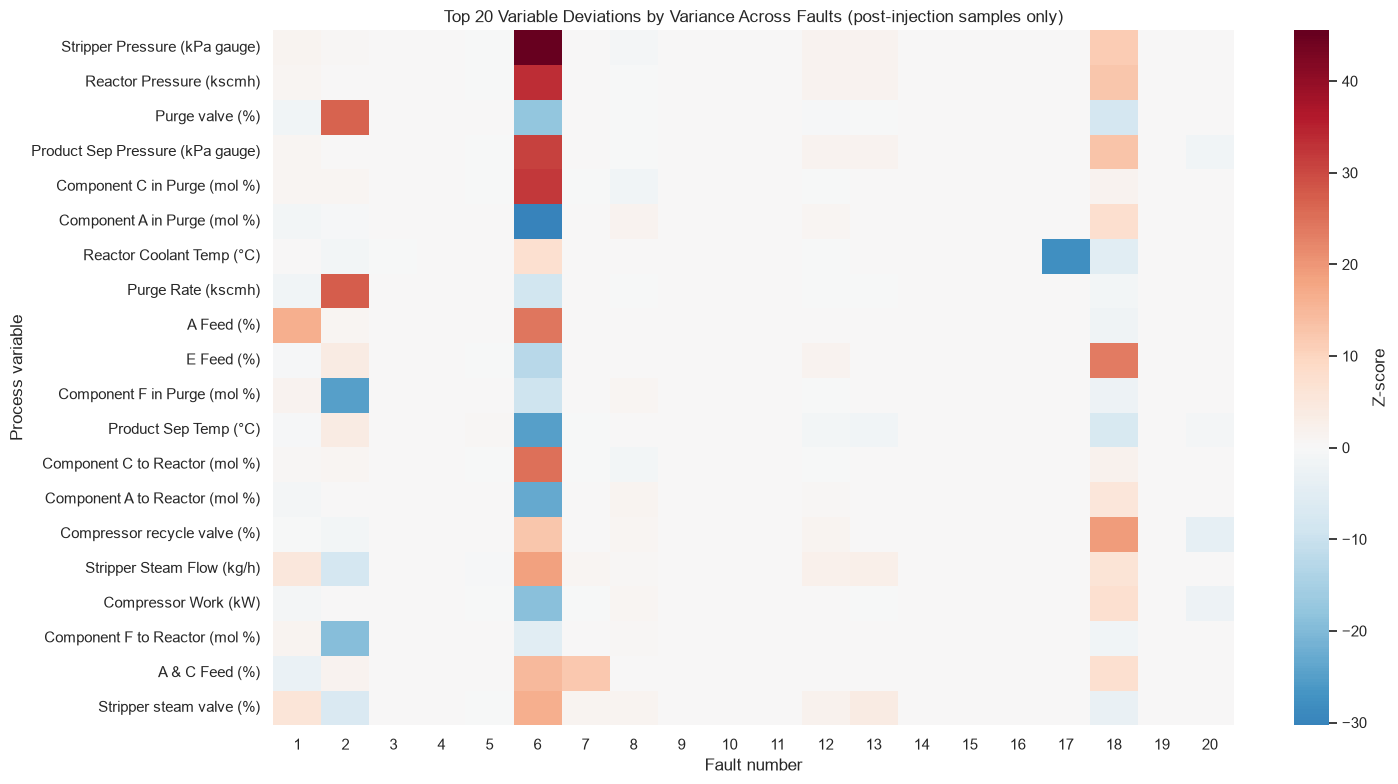

In [3]:
INFLECTION_POINT_TRAIN = 20 

mean_normal = df_fault_free_train[variables].mean()
std_normal = df_fault_free_train[variables].std()

post_fault = df_faulty_train[df_faulty_train["sample"] > INFLECTION_POINT_TRAIN]
stats_faults = post_fault.groupby("faultNumber")[variables].mean()

z_scores = (stats_faults - mean_normal) / std_normal

top_vars = z_scores.var().nlargest(20).index

plt.figure(figsize=(15, 8))
sns.heatmap(z_scores[top_vars].T, cmap="RdBu_r", center=0, cbar_kws={"label": "Z-score"})
plt.title("Top 20 Variable Deviations by Variance Across Faults (post-injection samples only)")
plt.xlabel("Fault number")
plt.ylabel("Process variable")
plt.tight_layout()
plt.show()


The heatmap illustrates the standardized deviations (Z-scores) of the top 20 process variables across the 20 TEP fault classes during the post-injection phase. Fault 6 exhibits the most severe and widespread system impact, driving extreme positive and negative shifts across pressure, flow, and composition metrics. Other faults, like Fault 1, Fault 2 and Fault 18, show pronounced localized deviations affecting specific parameters like valve positions, cooling temperatures, and component concentrations, while several other faults maintain comparatively mild variations across these key dimensions.

## 6. Fault Signature: Time-Series Comparison vs. the Fault-Free Baseline

For a chosen simulation run, we overlay the faulty trajectory on the fault-free trajectory of
the *same run index* for each of the top discriminative variables, with a vertical line
marking the fault-injection sample. This directly shows the fault's onset, its magnitude, and
whether the process reaches a new steady state or continues drifting.


In [5]:
SELECTED_FAULTS = [1, 2, 6, 18]

def compare_fault_free_vs_faulty(fault_numbers, simulation_run, variables=None):
    """Overlays faulty vs. fault-free time-series trajectories for a specific simulation run.

    Args
    fault_numbers : int or list of int
        Fault ID(s) to overlay against the baseline.
    simulation_run : int
        Index of the simulation run to compare.
    variables : list of str, optional
        Specific variable names to plot. If None, defaults to top discriminative variables.

    """
    if variables is None:
        variables = df_faulty_train.columns.drop(["faultNumber", "simulationRun", "sample"]).tolist()
    if isinstance(fault_numbers, int):
        fault_numbers = [fault_numbers]

    if simulation_run not in df_fault_free_train["simulationRun"].unique():
        print(f"Simulation run {simulation_run} not found in the fault-free data.")
        return
    if simulation_run not in df_faulty_train["simulationRun"].unique():
        print(f"Simulation run {simulation_run} not found in the faulty data.")
        return

    run_ff = df_fault_free_train[df_fault_free_train["simulationRun"] == simulation_run]

    num_features = len(variables)
    num_cols = min(4, num_features)
    num_rows = -(-num_features // num_cols) 

    for f_id in fault_numbers:
        run_f = df_faulty_train[(df_faulty_train["faultNumber"] == f_id) &
                                 (df_faulty_train["simulationRun"] == simulation_run)]
        if run_f.empty:
            print(f"Fault {f_id} + run {simulation_run} combination not found, skipping.")
            continue

        print(f"\nComparing Fault {f_id} vs. Fault-Free in run {simulation_run}")

        fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
        axes = np.atleast_1d(axes).flatten()

        for i, var in enumerate(variables):
            axes[i].plot(run_ff["sample"], run_ff[var], label="Fault Free", color="#1f77b4", alpha=0.6)
            axes[i].plot(run_f["sample"], run_f[var], label=f"Fault {f_id}", color="#e31a1c", alpha=0.6)
            axes[i].axvline(x=INFLECTION_POINT_TRAIN, color="black", linestyle="--", alpha=0.6)
            axes[i].set_title(var, fontsize=10)
            axes[i].set_xlabel("Sample number")
            axes[i].grid(True, linestyle=":", alpha=0.6)
            if i == 0:
                axes[i].legend()

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()



Comparing Fault 1 vs. Fault-Free in run 19


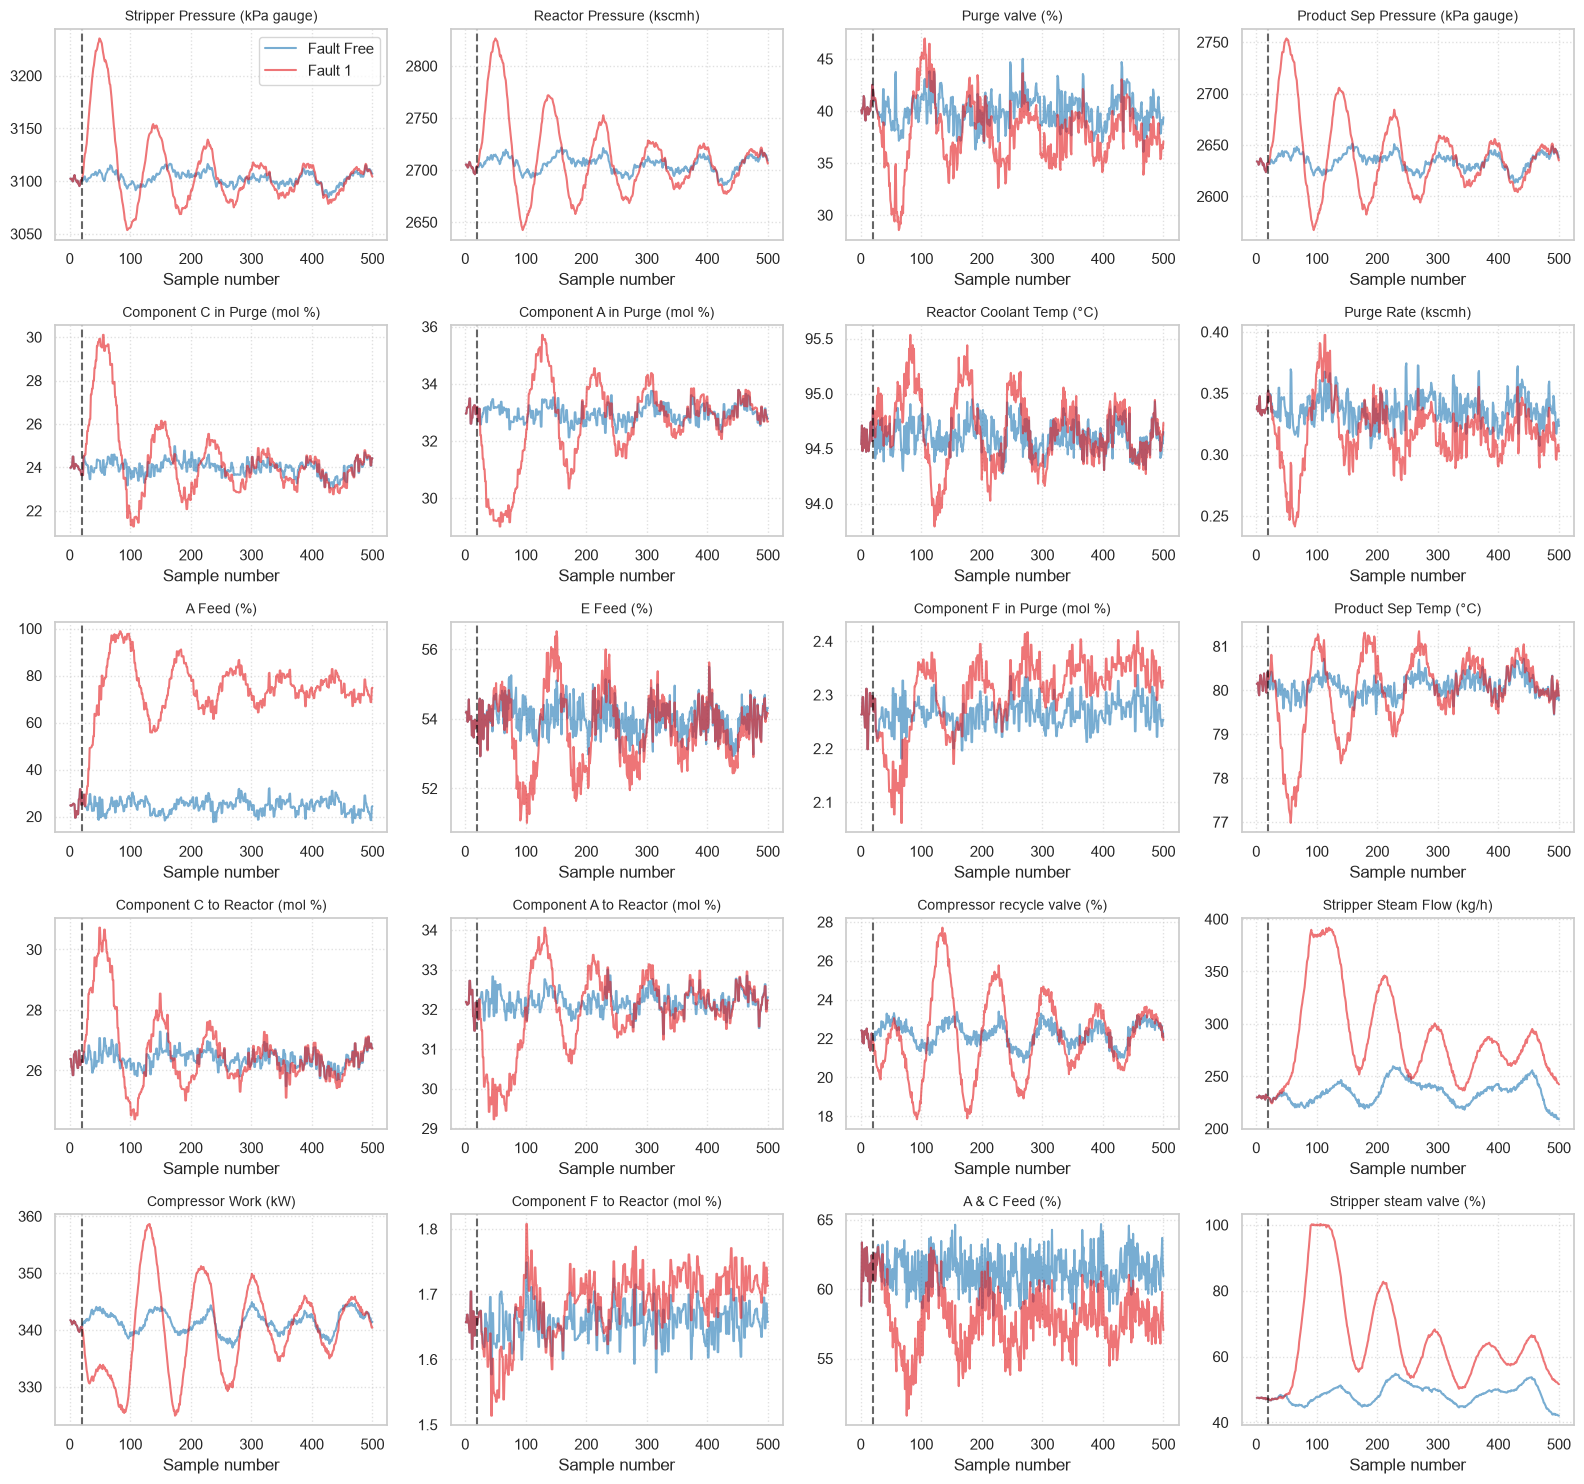


Comparing Fault 2 vs. Fault-Free in run 19


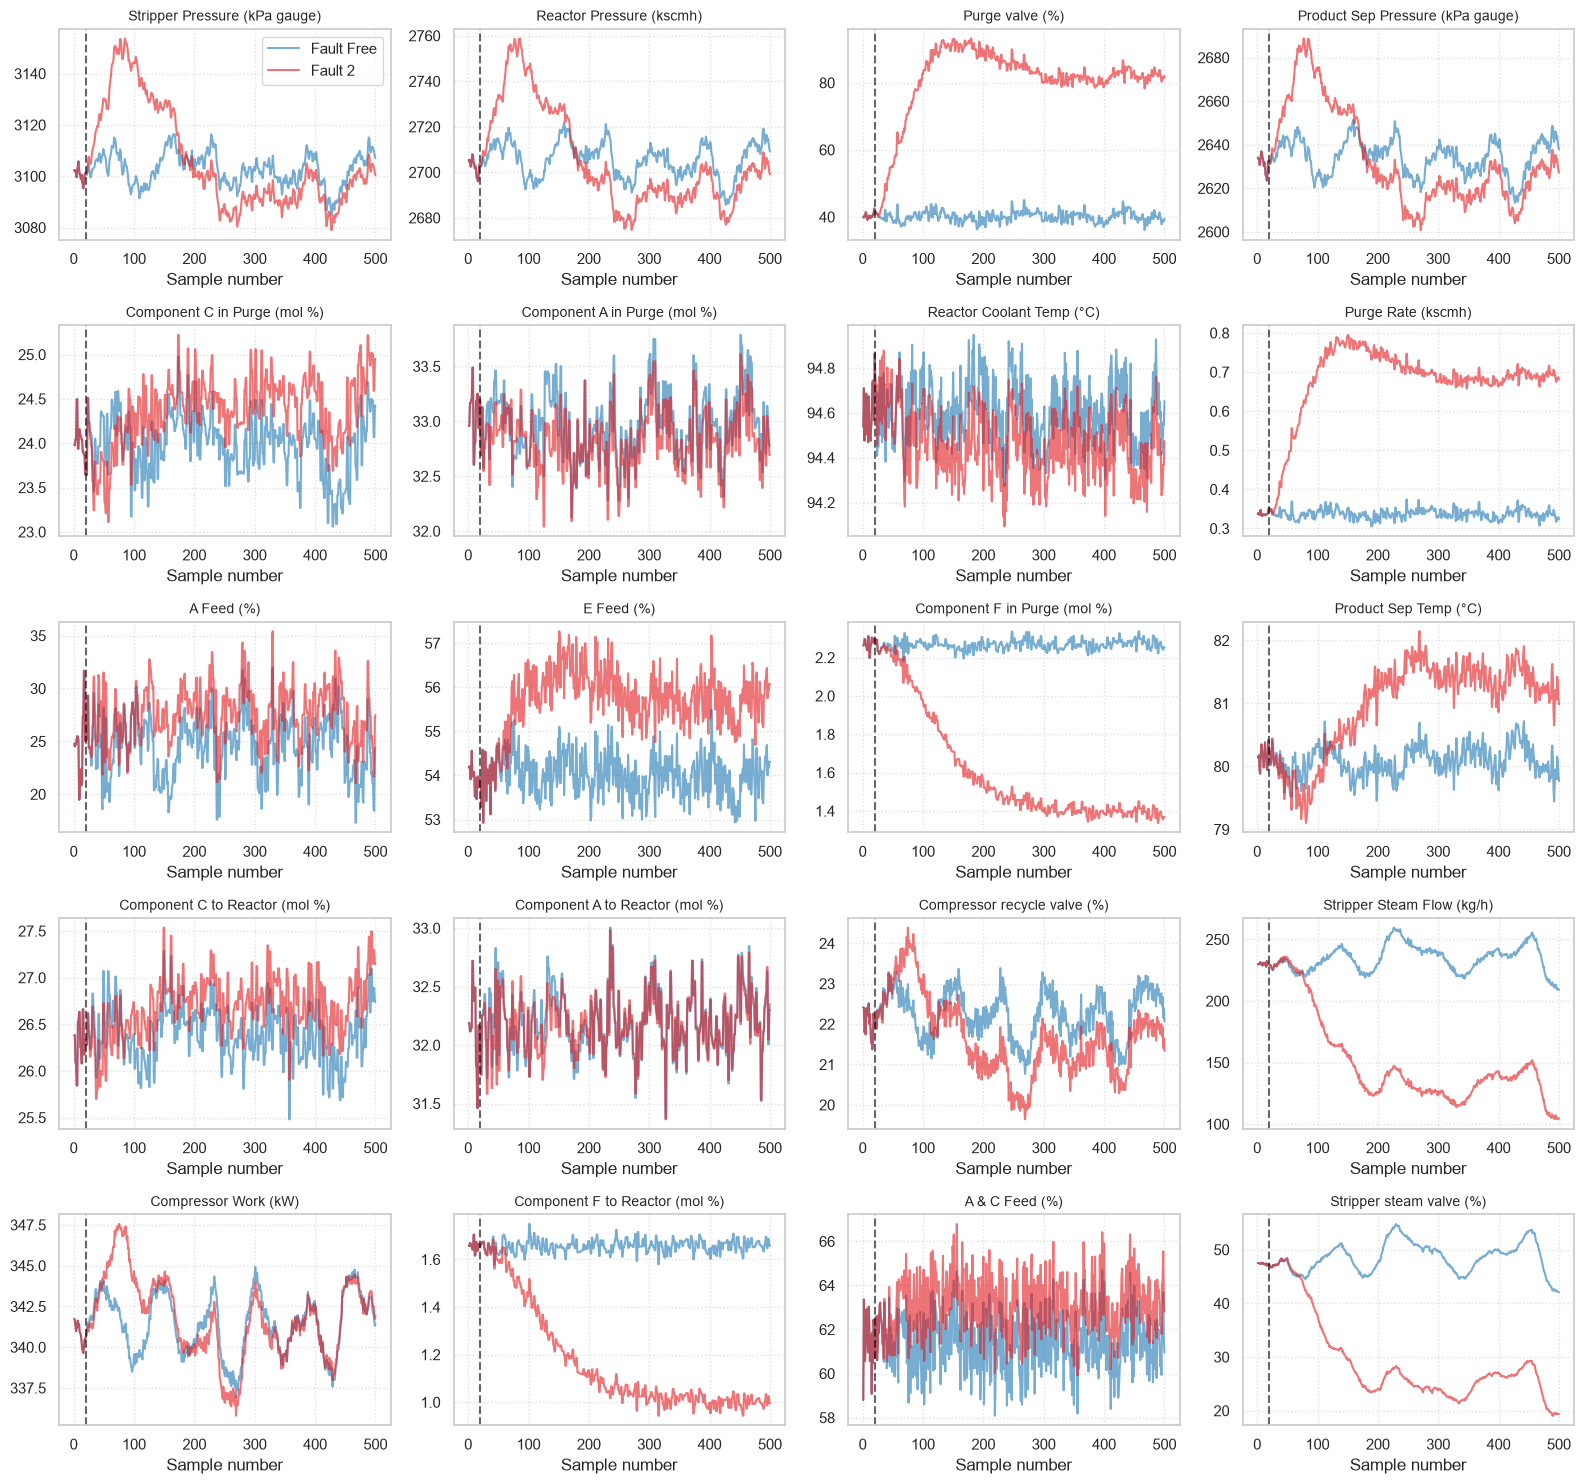


Comparing Fault 6 vs. Fault-Free in run 19


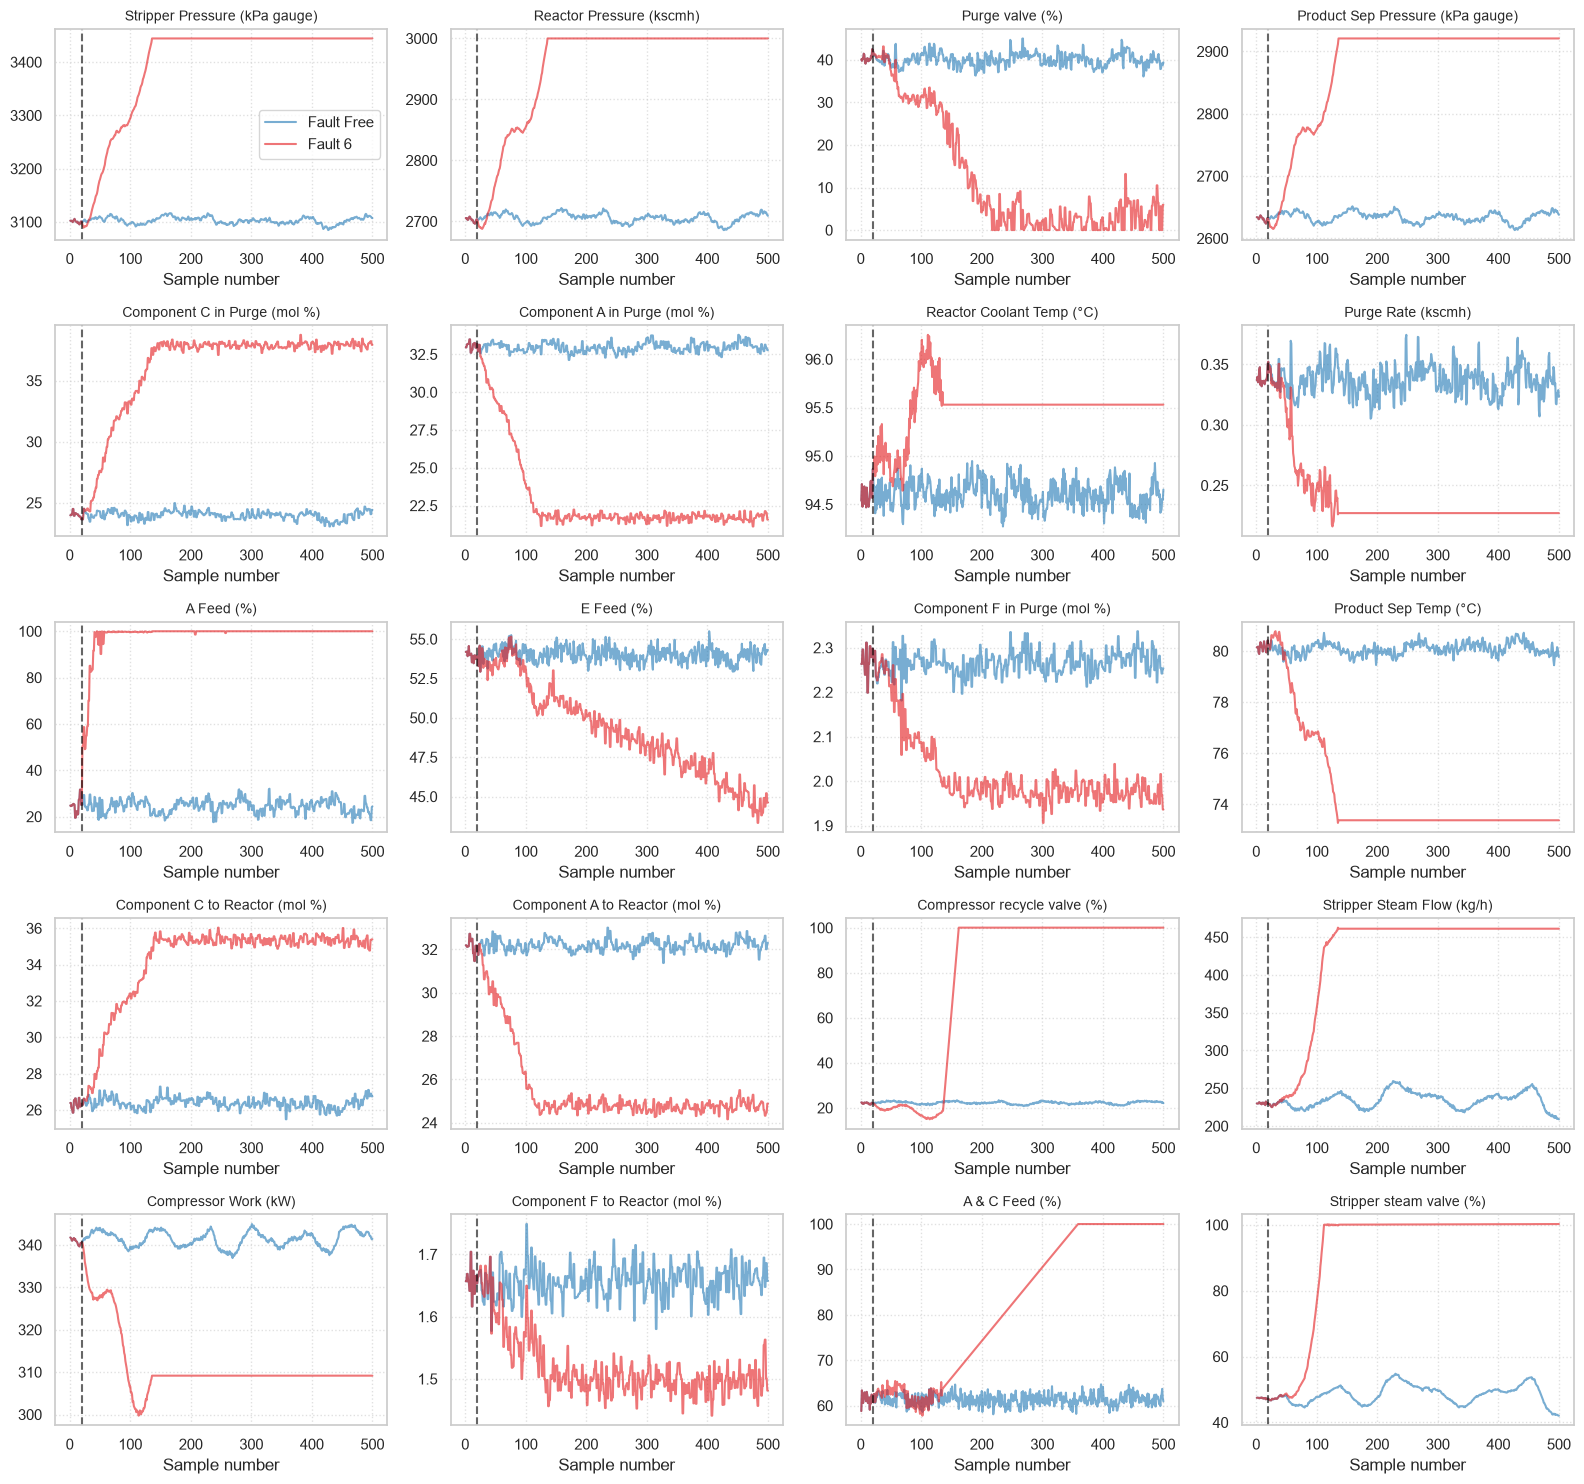


Comparing Fault 18 vs. Fault-Free in run 19


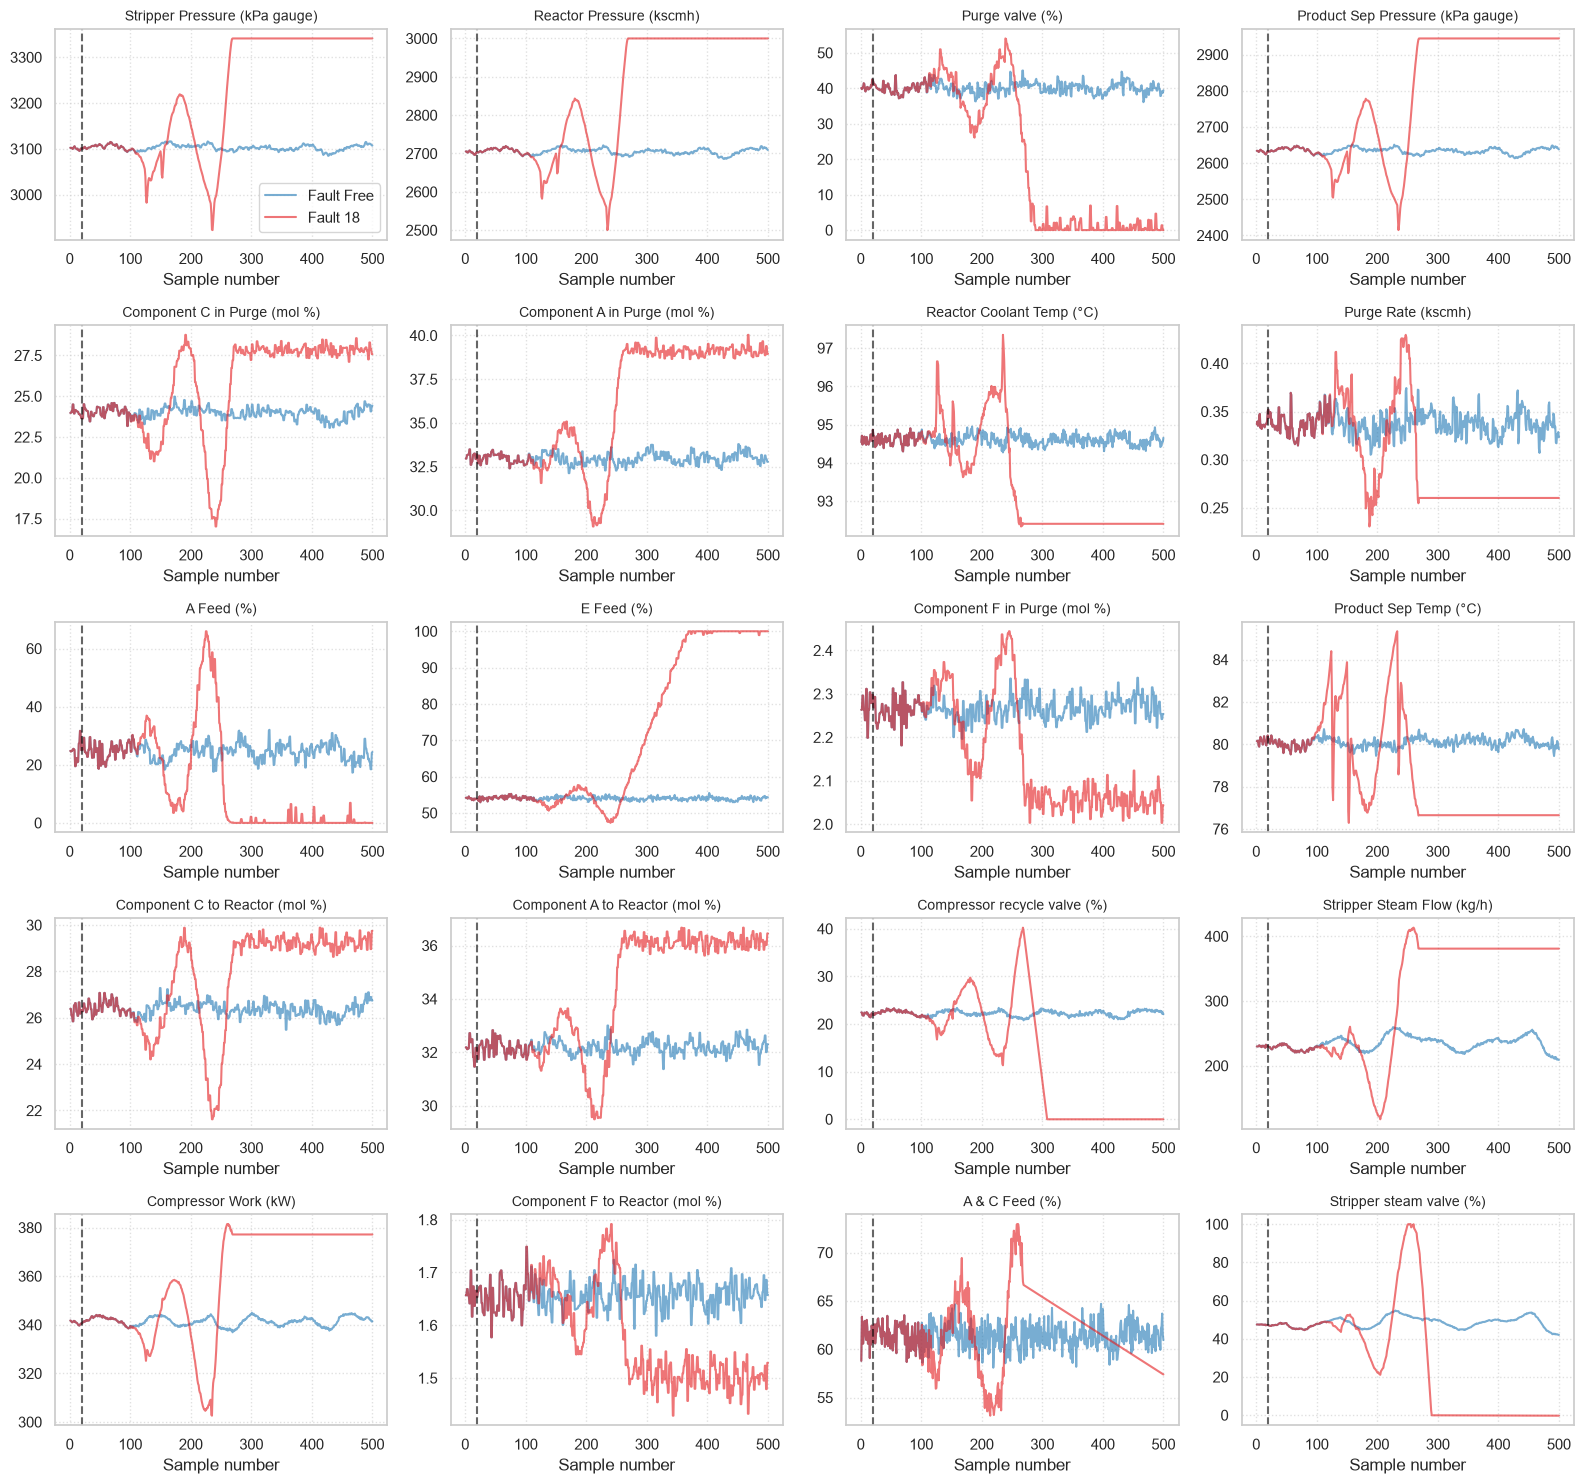

In [9]:
compare_fault_free_vs_faulty(fault_numbers=SELECTED_FAULTS, simulation_run=19, variables=top_vars)


For most faults, the manifestation of the anomaly becomes clearly visible immediately after injection (sample 20), whereas Fault 18 exhibits a noticeable delay before its transition occurs. Fault 1 induces pronounced oscillatory or transitional behaviors across core variables. Fault 2 exhibits oscillatory behavior for some variables and transitional behaviors for others before stabilizing. In contrast, Fault 6 triggers an immediate, aggressive, and permanent deviation that forces multiple process measurements far away from baseline conditions. Fault 18 displays sharp transient fluctuations followed by delayed step transitions, illustrating complex multi-phase dynamics that provide a robust benchmark for analyzing domain shift and transfer penalty.

## 7. Fault Consistency Analysis Across Simulation Runs

This evaluates the reproducibility of each fault's signature: for every time step, we compute
the standard deviation of each variable across all 500 simulation runs of a given fault. Low
values indicate a highly reproducible fault signature while high
values indicate that the initial random seed has a strong effect on how the fault manifests.
The vertical structure around `sample = 20` (fault injection) is the pattern to look for.


Processing coherence for Fault 1


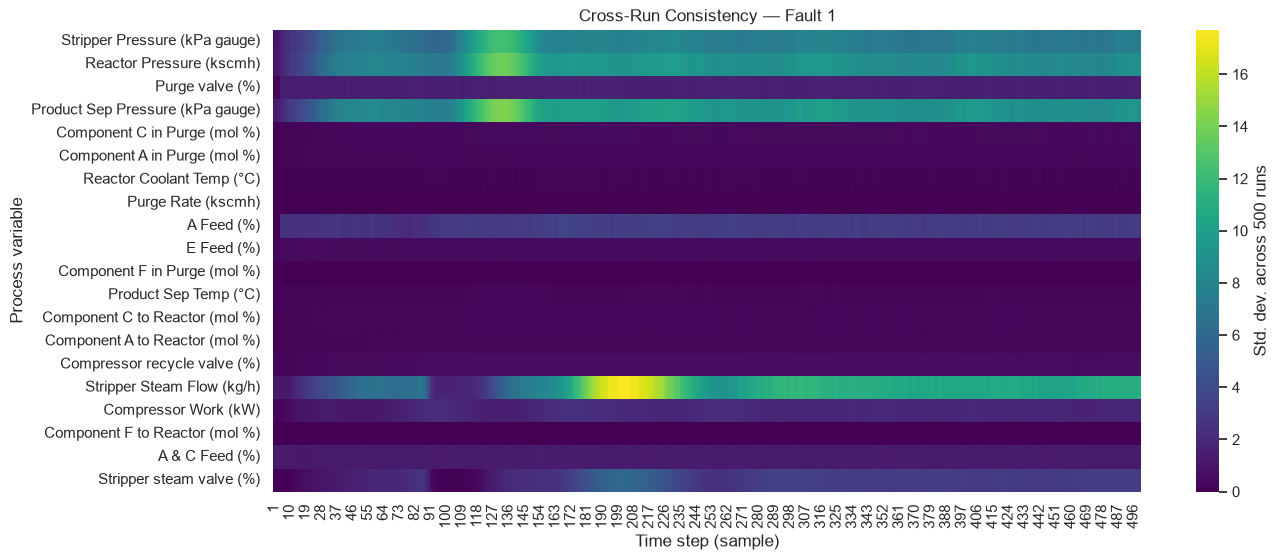

Processing coherence for Fault 2


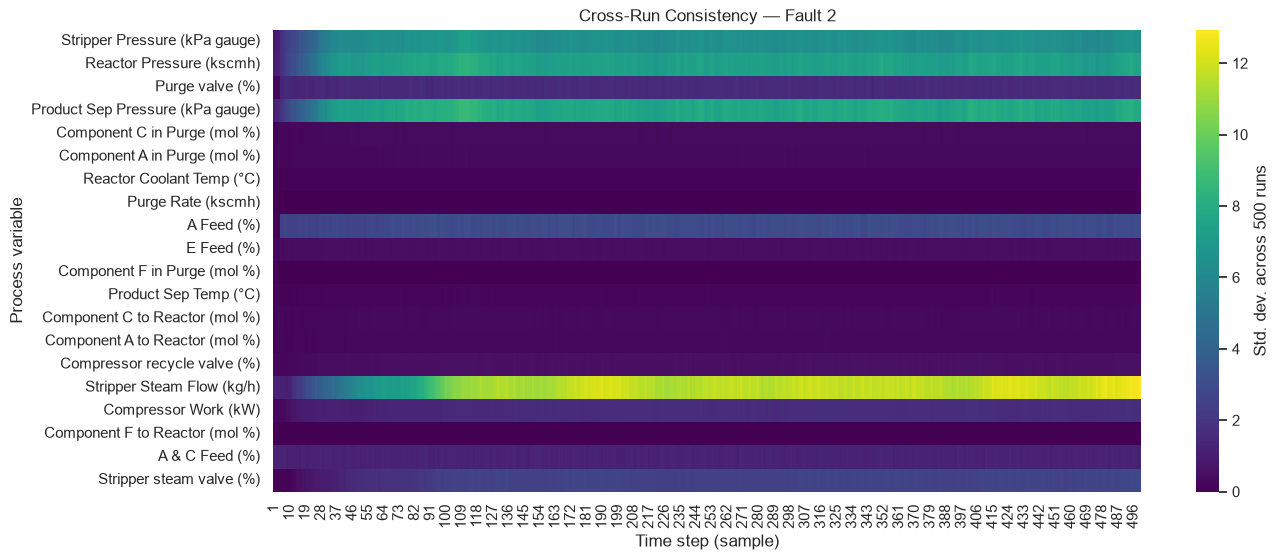

Processing coherence for Fault 5


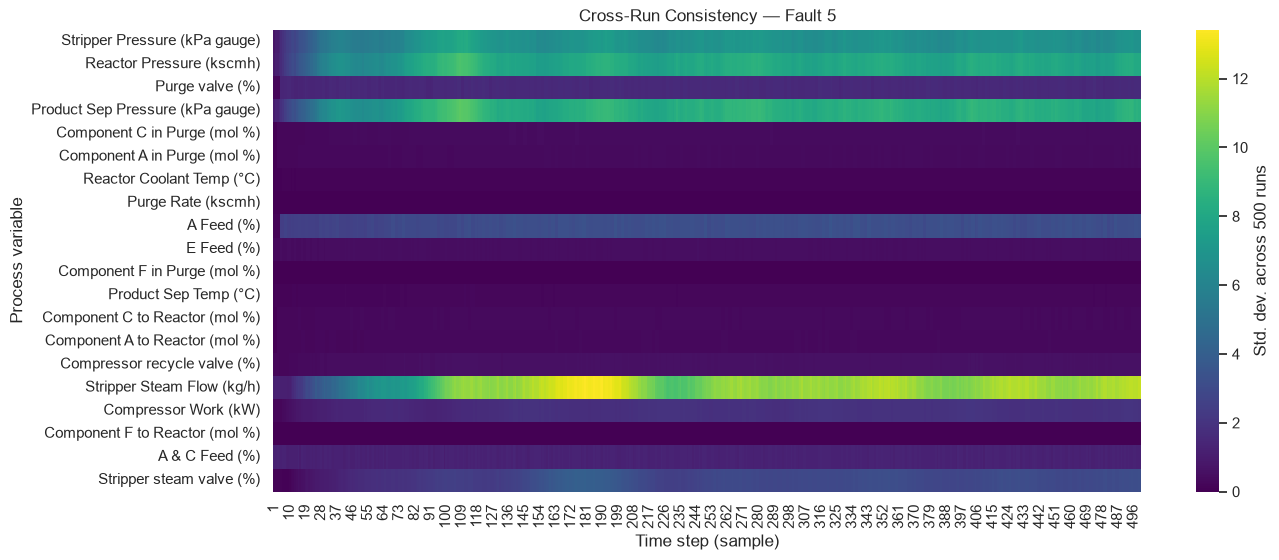

Processing coherence for Fault 6


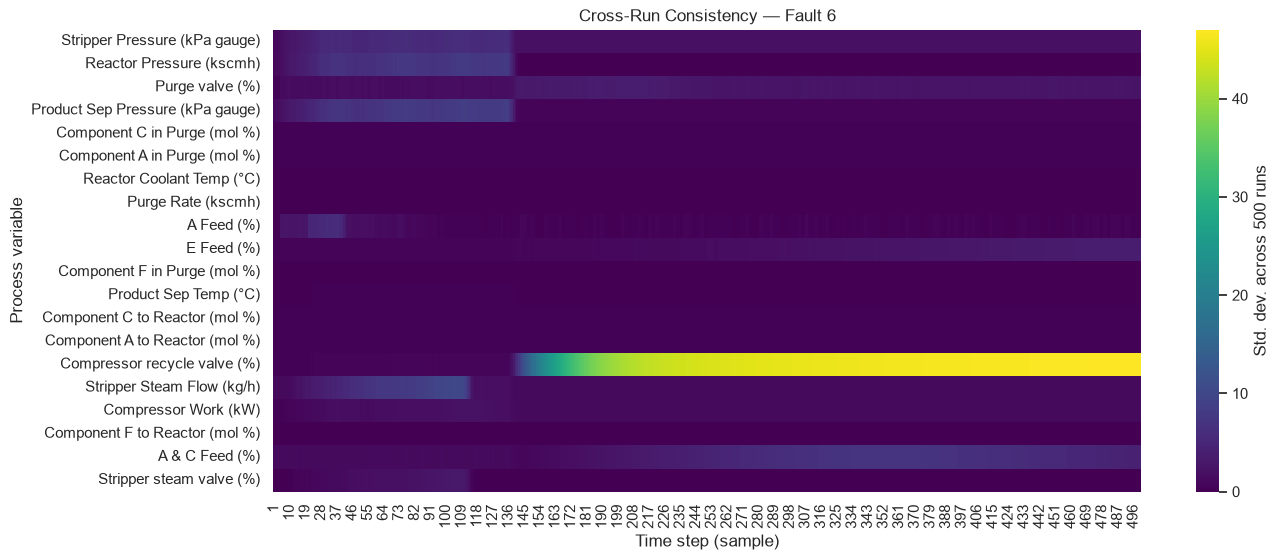

Processing coherence for Fault 10


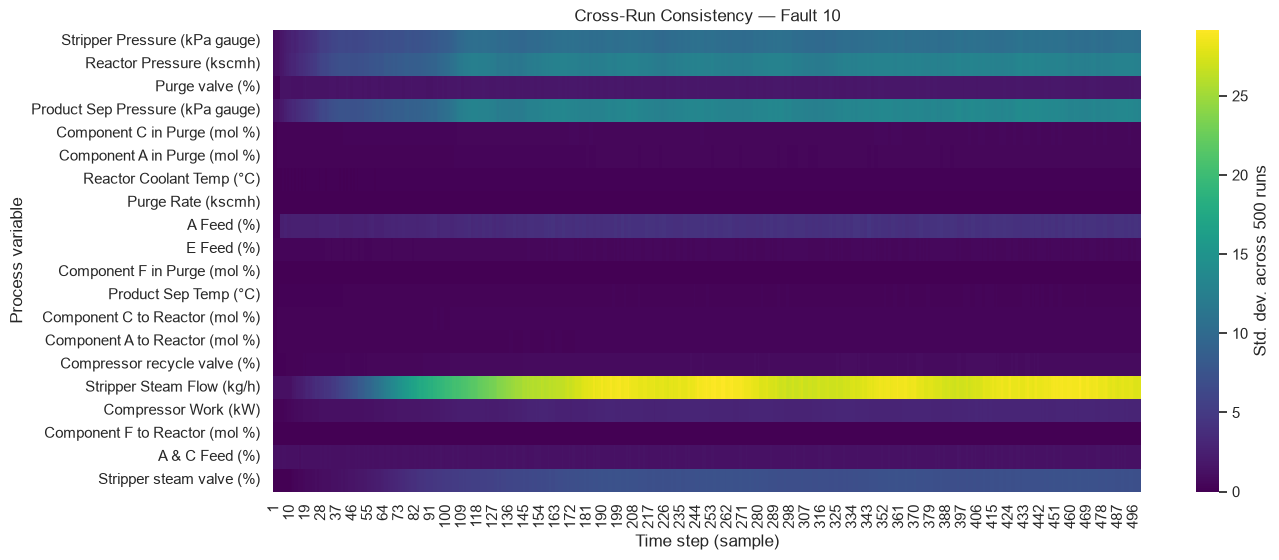

Processing coherence for Fault 18


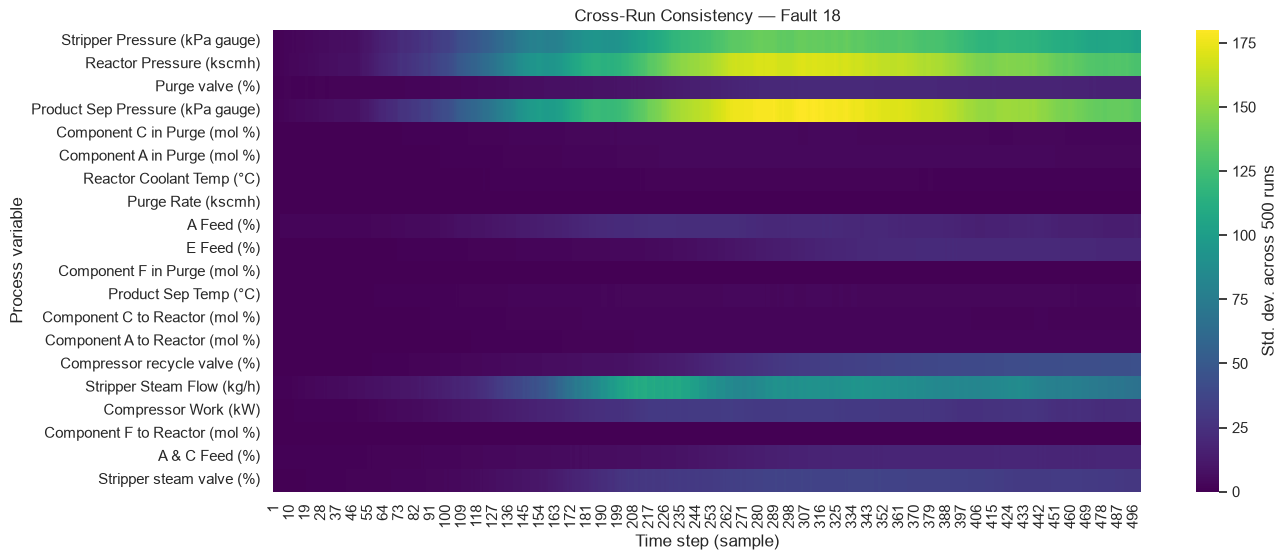

Processing coherence for Fault 20


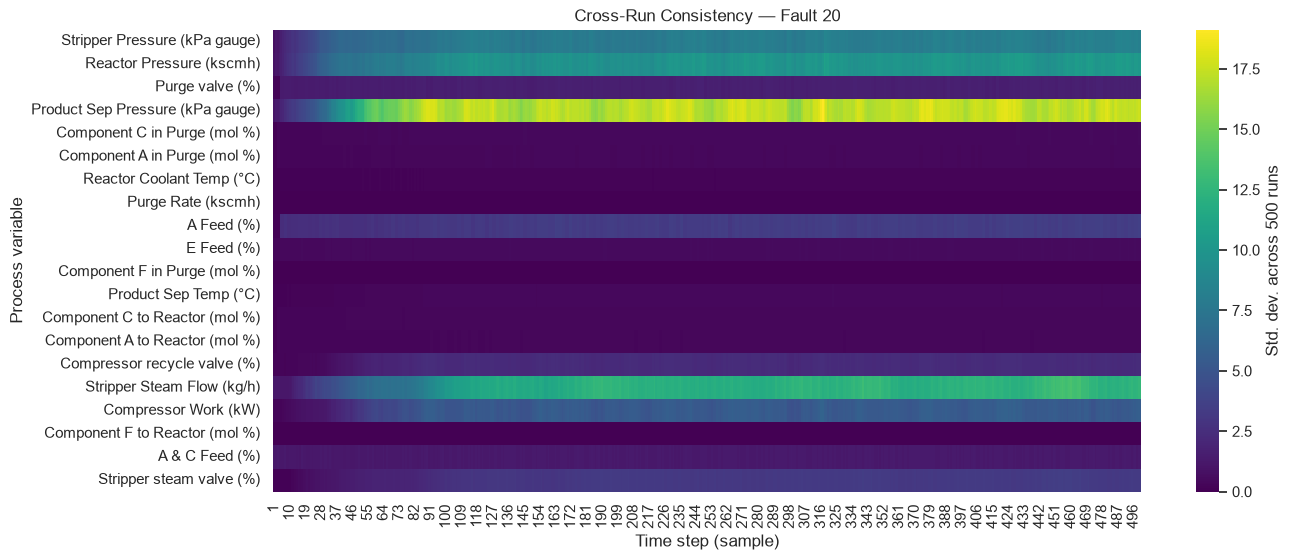

In [8]:
def get_run_coherence(fault_numbers, variables):
    """Compute cross-run standard deviation across 500 simulation runs to assess reproducibility.

    Generates heatmaps of timestep standard deviation per process variable.

    Args:
        fault_numbers (int | list): Fault ID(s) to evaluate.
        variables (list): Process variable names to analyze.

    Returns:
        None: Displays cross-run standard deviation heatmap.
    """
    if isinstance(fault_numbers, int):
        fault_numbers = [fault_numbers]

    invalid_vars = [v for v in variables if v not in df_faulty_train.columns]
    if invalid_vars:
        print(f"Error: the following variables do not exist in the dataset: {invalid_vars}")
        return

    for f_id in fault_numbers:
        if f_id not in df_faulty_train["faultNumber"].unique():
            print(f"Error: fault {f_id} is not present in the dataset.")
            continue

        print(f"Processing coherence for Fault {f_id}")
        data = df_faulty_train[df_faulty_train["faultNumber"] == f_id]
        coherence = data.groupby("sample")[variables].std()

        plt.figure(figsize=(14, 6))
        sns.heatmap(coherence.T, cmap="viridis", cbar_kws={"label": "Std. dev. across 500 runs"})
        plt.title(f"Cross-Run Consistency \u2014 Fault {f_id}")
        plt.xlabel("Time step (sample)")
        plt.ylabel("Process variable")
        plt.show()


get_run_coherence(fault_numbers=[1, 2, 5, 6, 10, 18, 20], variables=top_vars)


Cross-run consistency heatmaps reveal that process variability typically shifts around sample 20, marking the exact inflection point where fault injection alters system dynamics across different anomaly types. While each fault class displays a unique temporal signature dictated by its physical mechanism, Fault 6 introduces a particularly striking pattern. Although most process variables remain tightly reproducible across the 500 independent runs, the Compressor recycle valve (%) exhibits an abrupt and massive surge in cross-run standard deviation starting around sample 136, highlighting a phase where the controller's response or the system's settling behavior becomes heavily sensitive and variable across simulations.

## 9. Statistical Distribution ("Signature") Analysis

Box plots of each variable's post-injection value distribution within a single simulation
run, one figure per fault. This characterizes the "signature" of a fault as a static
distribution shape (spread, skew, outliers) rather than a temporal trajectory.


Variable distribution analysis for Fault 1 in run 90


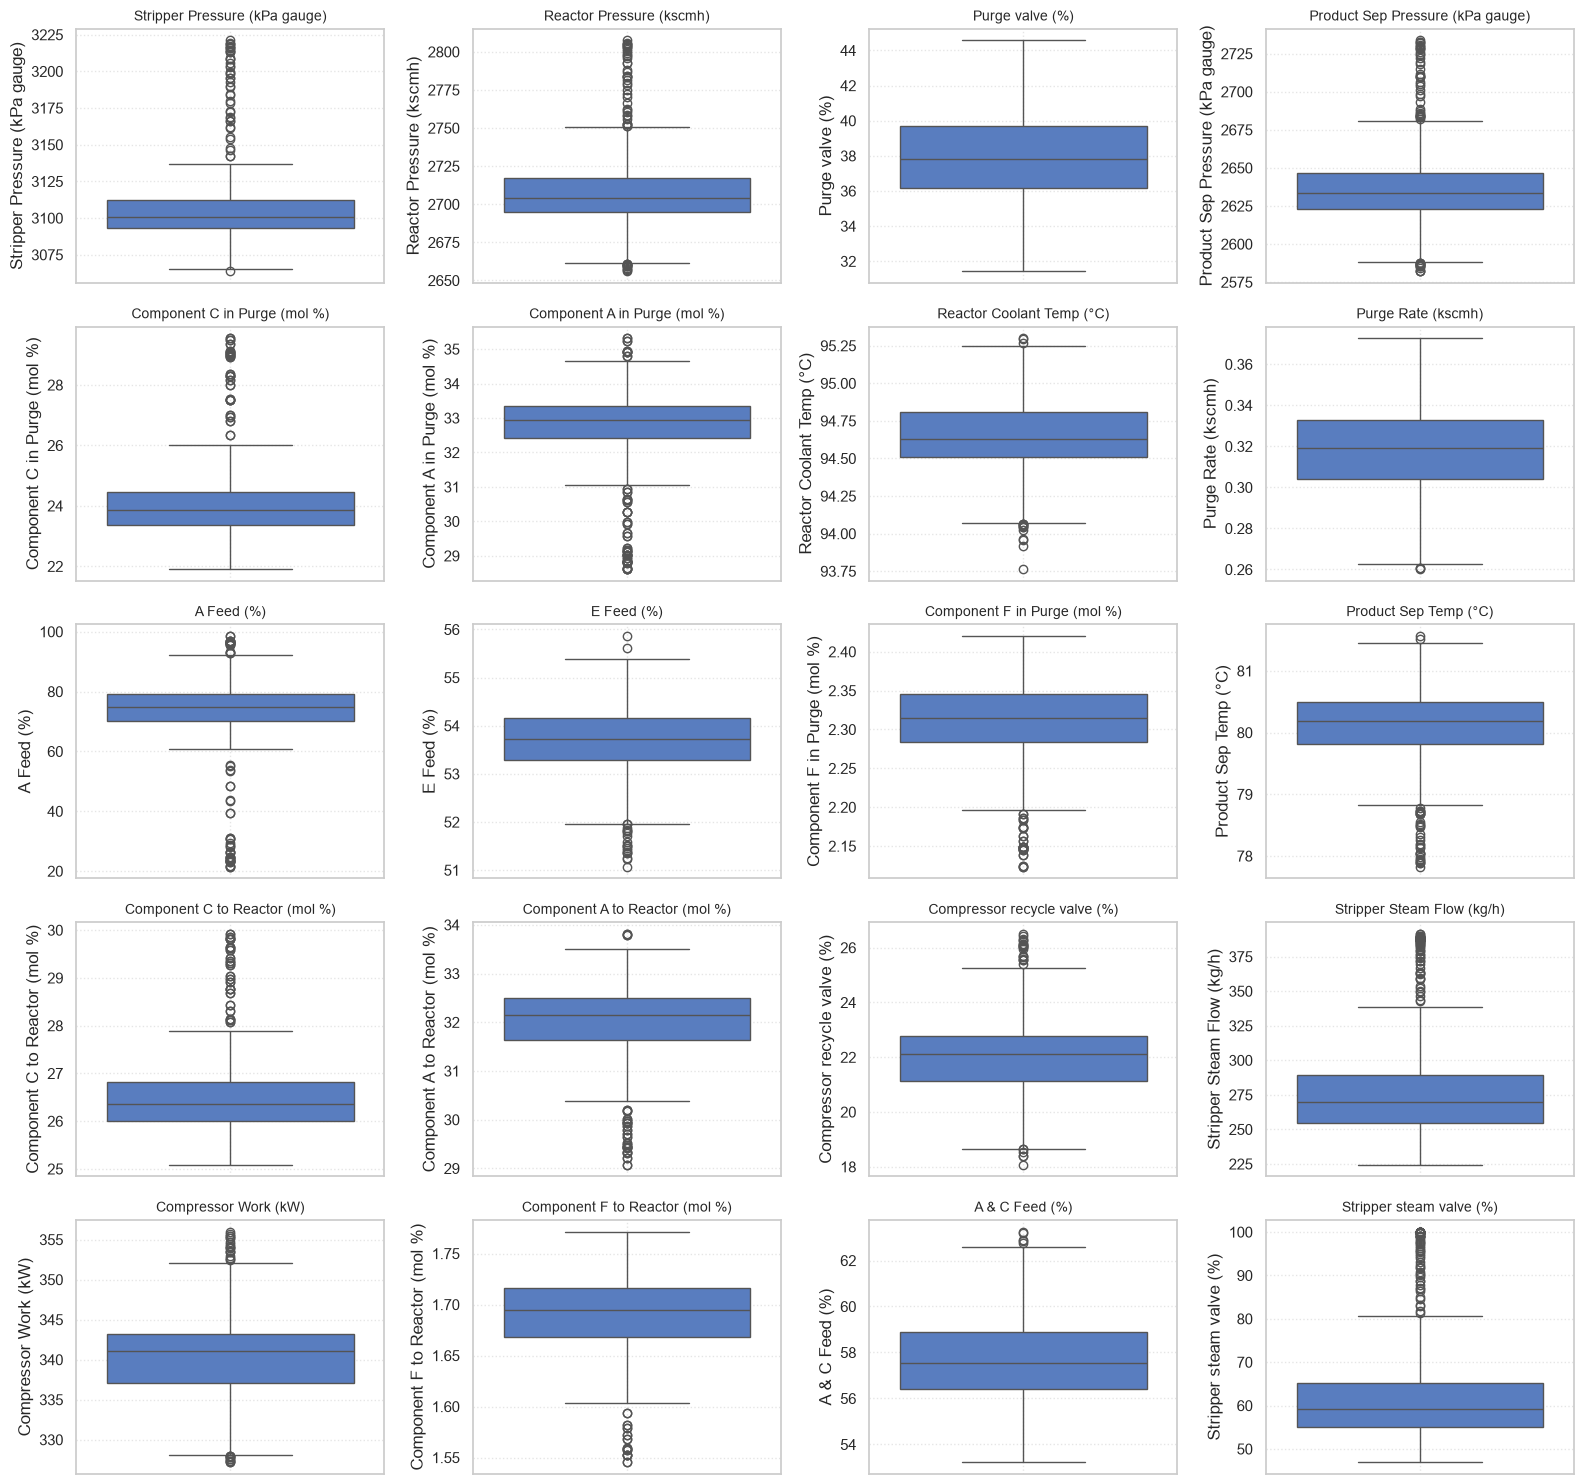


Variable distribution analysis for Fault 2 in run 90


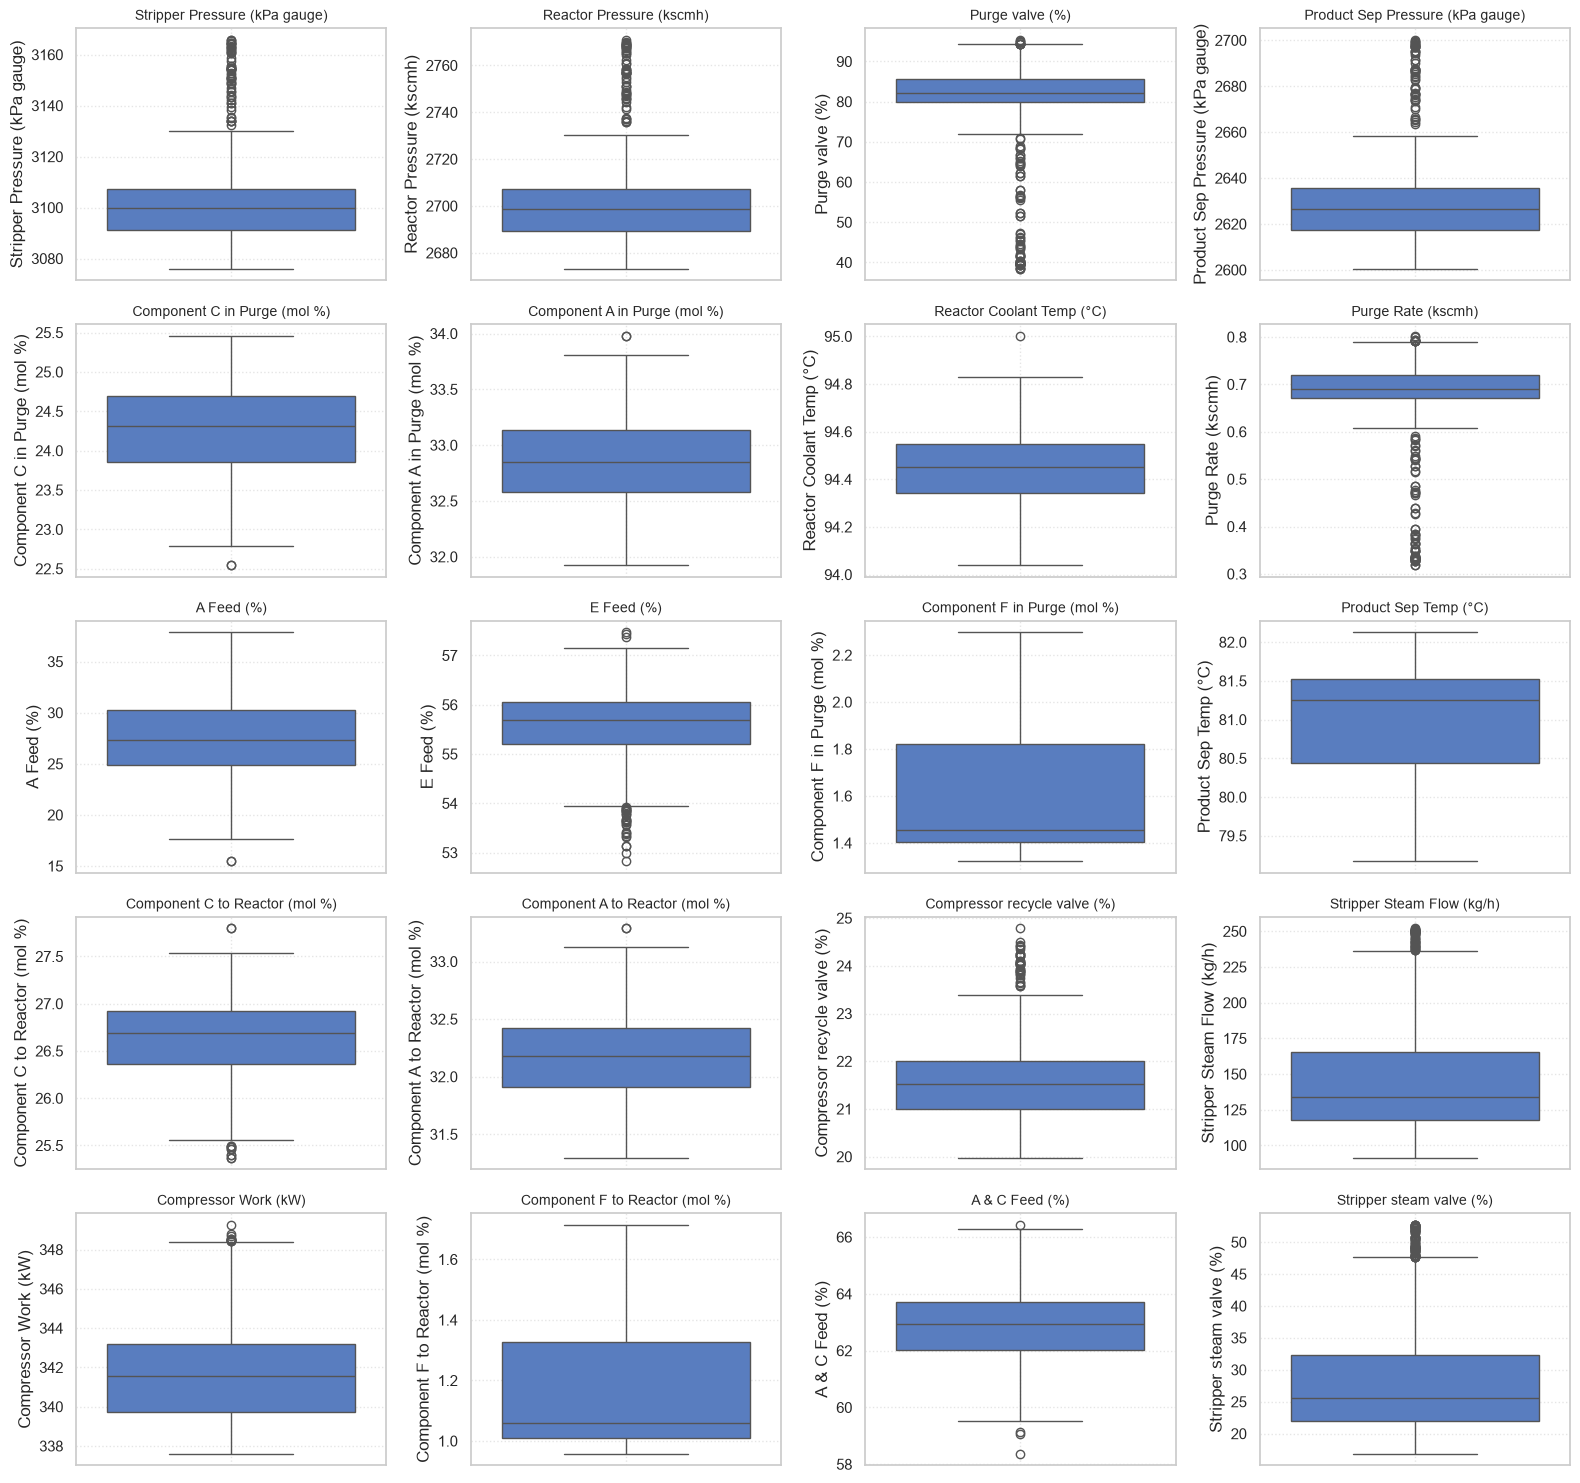


Variable distribution analysis for Fault 6 in run 90


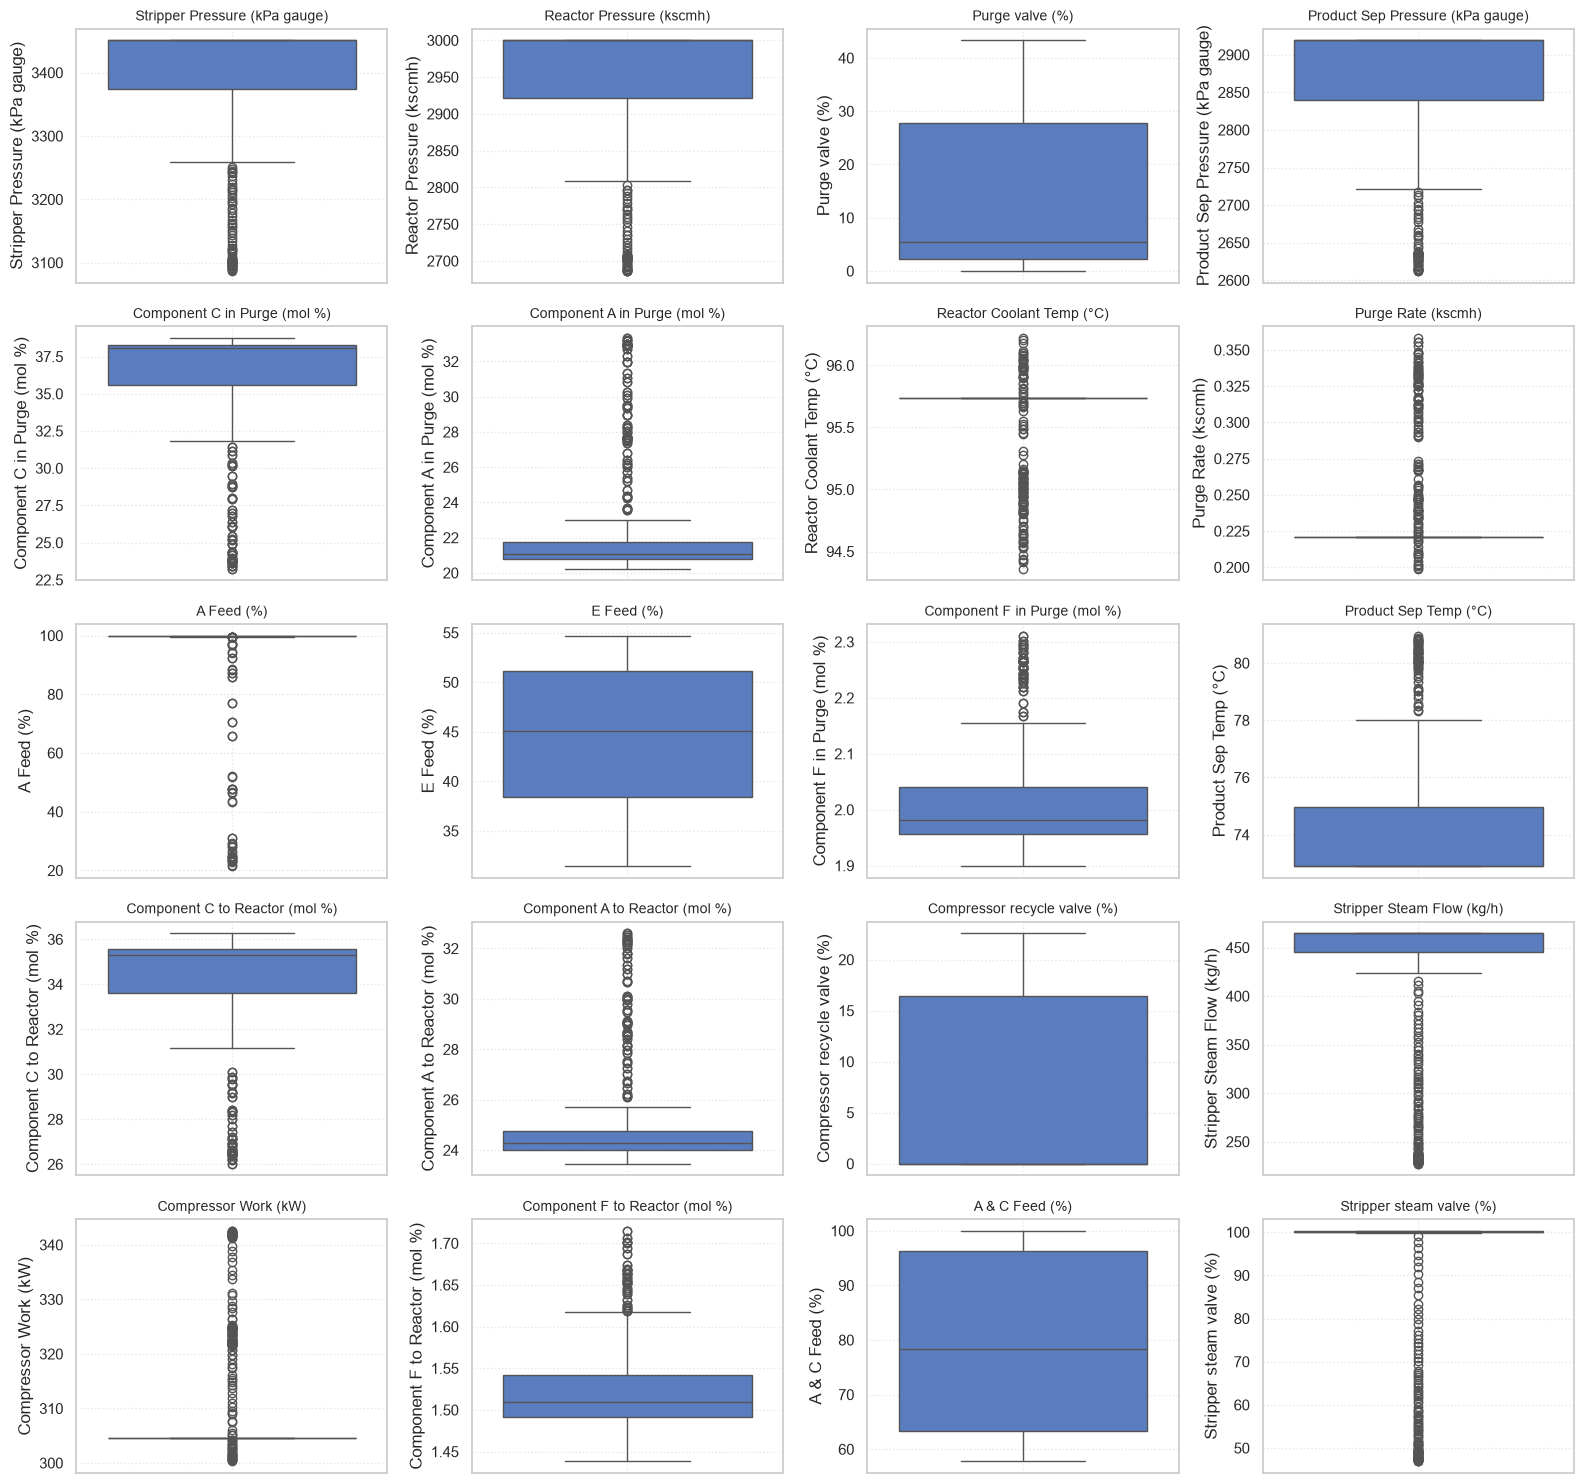


Variable distribution analysis for Fault 18 in run 90


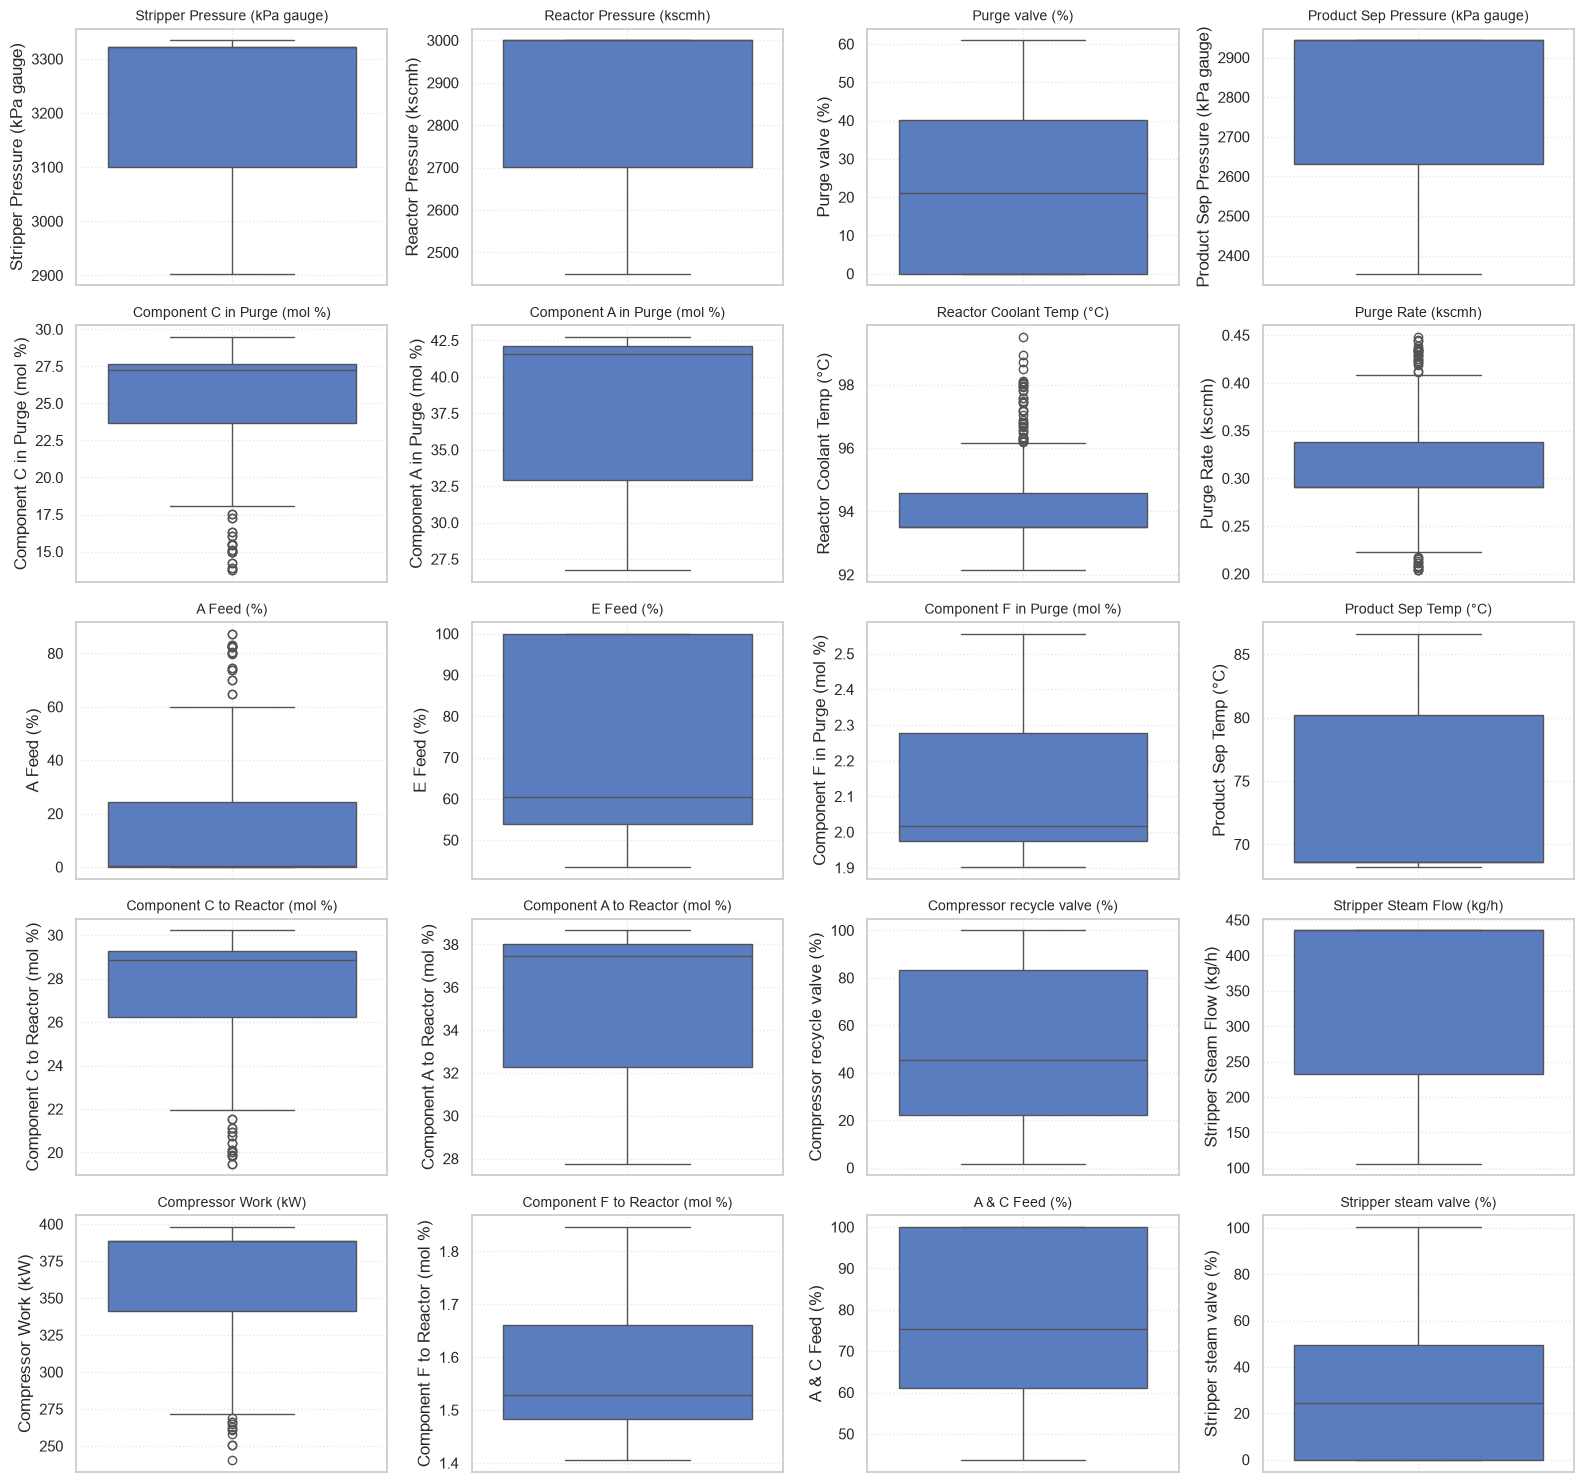

In [7]:
def plot_fault_distribution(fault_numbers, simulation_run=1, variables=None):
    """Generate box plots of post-injection variable distributions for signature analysis.

    Args:
        fault_numbers (int | list): Fault ID(s) to plot.
        simulation_run (int): Simulation run index to analyze.
        variables (list, optional): Process variable names to include.

    Returns:
        None: Displays seaborn boxplots of feature distributions.
    """
    if variables is None:
        variables = df_faulty_train.columns.drop(["faultNumber", "simulationRun", "sample"]).tolist()
    if isinstance(fault_numbers, int):
        fault_numbers = [fault_numbers]

    if simulation_run not in df_faulty_train["simulationRun"].unique():
        print(f"Simulation run {simulation_run} not found.")
        return

    num_features = len(variables)
    num_cols = min(4, num_features)
    num_rows = -(-num_features // num_cols)

    for f_id in fault_numbers:
        data = df_faulty_train[(df_faulty_train["faultNumber"] == f_id) &
                                (df_faulty_train["simulationRun"] == simulation_run)]
        if data.empty:
            print(f"Fault {f_id} + run {simulation_run} combination not found, skipping.")
            continue

        print(f"\nVariable distribution analysis for Fault {f_id} in run {simulation_run}")

        fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
        axes = np.atleast_1d(axes).flatten()

        for i, var in enumerate(variables):
            sns.boxplot(data=data, y=var, ax=axes[i])
            axes[i].set_title(var, fontsize=10)
            axes[i].grid(True, linestyle=":", alpha=0.5)

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()



plot_fault_distribution(fault_numbers=SELECTED_FAULTS, simulation_run=90, variables=top_vars)


Faults $1$ and $2$ maintain relatively tight interquartile ranges with noticeable outlier streams, reflecting stable core operation interrupted by localized step changes. In contrast, Fault $6$ exhibits massive distributional shifts and compressed or heavily skewed variance profiles across key variables like stripper pressure and feed rates, confirming its severe systemic impact. Fault $18$ displays wide, highly dispersed distributions spanning the entire operational envelope, highlighting its complex, multi-phase perturbation profile.Building upon these distinct distributional signatures, summary statistics ($\text{Mean}, \text{Std}, \text{Min}, \text{Max}$) were chosen to capture the complete physical footprint of each fault class. While percentiles could theoretically offer additional granularity, they provide limited extra value here while remaining computationally expensive, making basic distribution metrics the ideal mathematical foundation for domain shift measurement (Stage 2) and conditional generative reconstruction (Stage 3).


## 10.  Summary  

This exploratory data analysis establishes the empirical foundation for the subsequent transfer learning and generative augmentation stages:

1. **Dataset Integrity & Scale**: The TEP dataset is a clean, balanced  benchmark across $20$ distinct fault mechanisms and $52$ continuous process variables, free from missing data or frozen sensors.
2. **Physical Disturbance Diversity**: Fault mechanisms span localized step changes, distributed stochastic variations, dynamic kinetic drifts, mechanical actuator stiction, and complex unknown perturbations.
3. **Temporal Dynamics**: Fault signatures evolve through an early transient regime (active controller hunting) before settling into steady-state equilibrium, justifying the use of $208$-dimensional sliding-window statistical descriptors ($52 \text{ variables} \times 4 \text{ summary statistics}$).
4. **Physical Reproducibility**: High cross-run coherence across $500$ simulation runs proves that fault signatures are almost reproducible, providing a reliable foundation for geometric domain distance estimation in Stage 2.

Having fully explored the physical characteristics and structural integrity of the TEP dataset, we proceed to stage 2 (Domain-shift diagnostics and transfer evaluation), where we quantify geometric domain distances ($\text{SWD}, \text{MMD}, \text{FD}$) and evaluate transfer penalty degradation across binary and multiclass operational settings.
